# The primary production time series (2012-2023) is available at NIOZ Dataverse at http://doi.org/10.25850/nioz/7b.b.5j

# For reference of this code asset, please refer to the file "CITATION.cff"

wd organization (always run first)

In [ ]:
# This notebook is used for analyzing time series of primary production collected at Jetty monitoring plattform:
#install.packages("plotly")
#install.packages("pracma")
library(mgcv)
library(ggplot2)
library(lubridate)
library(plotly)
library(dplyr)
library(pracma)

s3_path <- "/home/jovyan/Cloud Storage/naa-vre-user-data/S3_JettyPP_data/" # Please change this to your path
list.files(paste0(s3_path))

# wd organization (always run first)

#================================================================================
#     START OF USER DEFINED INPUT
#================================================================================
# setwd(wd_path)
# wd_path <- "/home/jovyan/Virtual Labs/Waddenzee proto DT/Git public/Jetty_PPts/"
wd_path <- s3_path

# Check if the directories exists
rawdata_dir = paste(wd_path,"/rawdata/",sep="")
processed_data_dir = paste(wd_path,"/processed_data/",sep="")
PI_output_dir = paste(wd_path,"/PI_output/",sep="")
PP_cal_dir = paste(wd_path,"/PP_cal/",sep="")
graph_dir = paste(wd_path,"/graphs/",sep="")

if (!dir.exists(wd_path)) {
  # Create the directory if it doesn't exist
  dir.create(wd_path, recursive = TRUE)
}
if (!dir.exists(rawdata_dir)) {
  # Create the directory if it doesn't exist
  dir.create(rawdata_dir, recursive = TRUE)
}
if (!dir.exists(PI_output_dir)) {
  # Create the directory if it doesn't exist
  dir.create(PI_output_dir, recursive = TRUE)
}
if (!dir.exists(processed_data_dir)) {
  # Create the directory if it doesn't exist
  dir.create(processed_data_dir, recursive = TRUE)
}
if (!dir.exists(PP_cal_dir)) {
  # Create the directory if it doesn't exist
  dir.create(PP_cal_dir, recursive = TRUE)
}
if (!dir.exists(graph_dir)) {
  # Create the directory if it doesn't exist
  dir.create(graph_dir, recursive = TRUE)
}



Loading required package: nlme

This is mgcv 1.9-3. For overview type 'help("mgcv-package")'.


Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union



Attaching package: ‘plotly’


The following object is masked from ‘package:ggplot2’:

    last_plot


The following object is masked from ‘package:stats’:

    filter


The following object is masked from ‘package:graphics’:

    layout



Attaching package: ‘dplyr’


The following object is masked from ‘package:nlme’:

    collapse


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘pracma’


The following object is masked from ‘package:mgcv’:

    magic




[1] "graphs"         "PI_output"      "PP_cal"         "processed_data"
[5] "rawdata"

# Figure 3 (A). Monthly mean Biomass

Loading required package: viridisLite

Warning message:
“The following aesthetics were dropped during statistical transformation: fill.
ℹ This can happen when ggplot fails to infer the correct grouping structure in
  the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical
  variable into a factor?”


[1] 10.82376

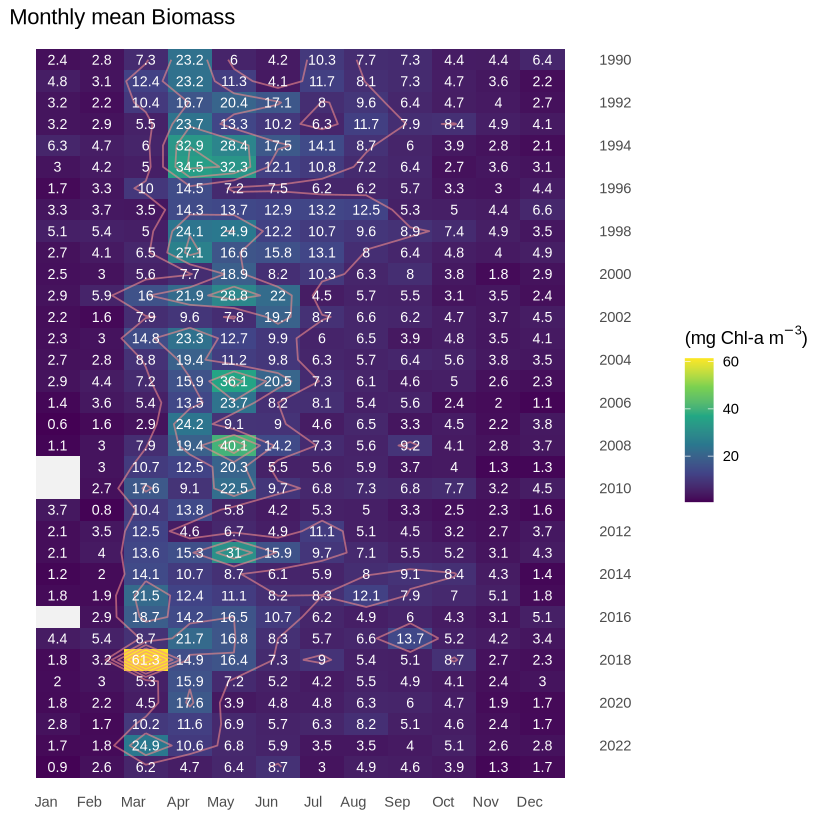

In [3]:
# Interannual phytoplankton dynamics: contour plot of monthly mean Chl-a
library(tidyr)
library(viridis)

Jetty_df = read.csv(file=paste(wd_path,"/processed_data/","Jetty_HWseries.csv",sep=""), fileEncoding = "UTF-8", na.strings=c("", "NA"), header=TRUE)
Jetty_df$timestamp <- Jetty_df$timestamp%>%ymd_hms()

Jetty_df$Year = year(Jetty_df$timestamp)
Jetty_df$month = month(Jetty_df$timestamp)
# Compute monthly means (year x month)

Jetty_df_1990_2023 <- Jetty_df %>% filter(Year >= 1990 & Year <= 2023)
monthly_chl <- Jetty_df_1990_2023 %>%
  mutate(year = year(timestamp), month = month(timestamp)) %>%
  group_by(year, month) %>%
  summarise(monthly_Chl = mean(Chl, na.rm = TRUE), .groups = 'drop')

# Ensure a complete year-month grid so tiles show gaps
years_seq <- seq(min(monthly_chl$year, na.rm = TRUE), max(monthly_chl$year, na.rm = TRUE))
monthly_chl <- monthly_chl %>% tidyr::complete(year = years_seq, month = 1:12)

# Replace NA monthly_Chl with NA (keeps gaps) or small value if wanted
# monthly_chl$monthly_Chl[is.na(monthly_chl$monthly_Chl)] <- NA

# Plot: filled tiles with contour lines to show long-term dynamics
min_year <- min(monthly_chl$year, na.rm = TRUE)
max_year <- max(monthly_chl$year, na.rm = TRUE)

p_contour <- ggplot(monthly_chl, aes(x = month, y = year, fill = monthly_Chl)) +
          geom_tile(color = NA) +
            # contour lines
          geom_contour(aes(z = monthly_Chl), color = "#f18d8d", alpha = 0.6, bins = 8, na.rm = TRUE) +
            # numeric labels inside tiles
          geom_text(aes(label = round(monthly_Chl, 1)), size = 3, na.rm = TRUE, color = "white") +
          scale_fill_viridis_c(
          option = "D",           # colorblind friendly
          na.value = "grey95",
          name = expression("(mg Chl-a m"^{-3}*")")
          ) +
          scale_x_continuous(breaks = 1:12, labels = month.abb) +
          scale_y_continuous(
            breaks = seq(min_year, max_year, by = 2),
            expand = expansion(add = c(0.5, 0.5)),
            trans = "reverse",
            position = "right"
          ) +
          labs(
          title = "Monthly mean Biomass",
          x = "",
          y = ""
          ) +
          theme_minimal() +
          theme(
          axis.text.x = element_text(angle = 0, hjust = 1),
          panel.grid = element_blank()
          )

print(p_contour)

Jetty_growth <- Jetty_df_1990_2023 %>%
  filter(month %in% 3:9)  %>% group_by(Year, month) %>%
  summarise(monthly_Chl_mean = mean(Chl, na.rm = TRUE), .groups = 'drop')

mean(Jetty_growth$monthly_Chl_mean, na.rm = TRUE)

# Optionally save
#ggsave(filename = paste(graph_dir, "monthly_Chl_contour.png", sep = ""), plot = p_contour, width = 7, height = 8, dpi = 300)



# Figure 3 (B). LT of Chla and PP

Intercept: 11.00321 
Slope: -0.1111599 
decline between 1990-2023 in xx%: -34.34849 


[1]  4.26600 13.87713


Call:
lm(formula = Chl_mean ~ ind, data = df_Chl_yearly)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.2364 -1.8141 -0.7319  1.8405  5.9864 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 11.11436    0.83792  13.264  1.5e-14 ***
ind         -0.11116    0.04177  -2.662   0.0121 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2.389 on 32 degrees of freedom
Multiple R-squared:  0.1812,	Adjusted R-squared:  0.1557 
F-statistic: 7.084 on 1 and 32 DF,  p-value: 0.01206


ind 
-1.000146

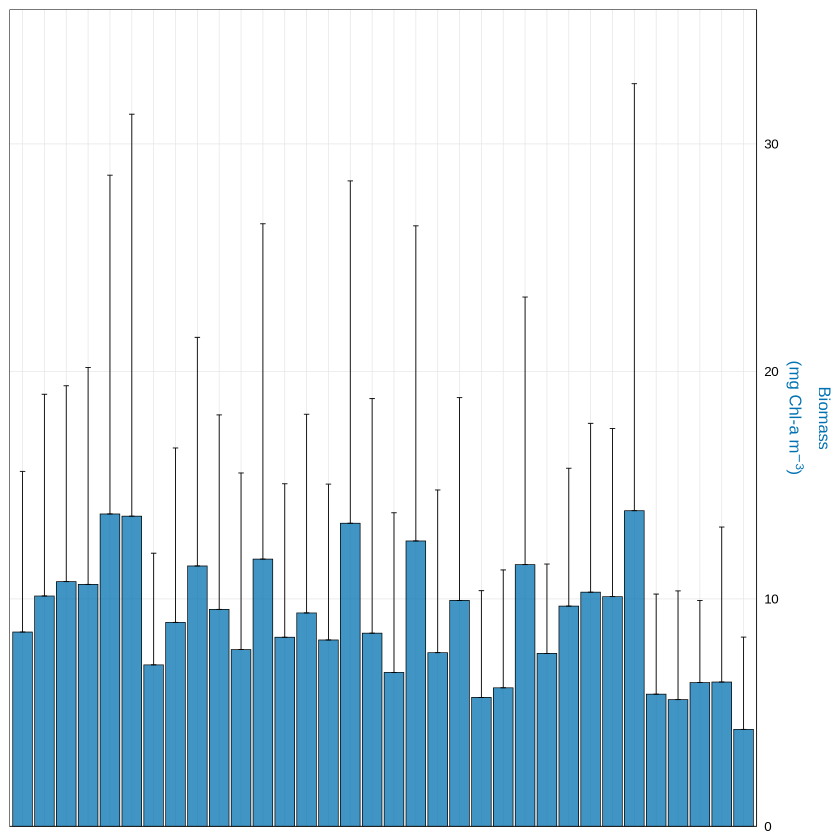

In [4]:
Jetty_df_1990_2023 <- Jetty_df %>% filter(Year >= 1990 & Year <= 2023)

# Annual means and SD for biomass and growth rate bars
df_Chl_yearly <- Jetty_df_1990_2023 %>%
  group_by(Year) %>%
  summarise(
    Chl_mean = mean(Chl, na.rm = TRUE),
    Chl_sd = sd(Chl, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  filter(!is.na(Year), !is.nan(Chl_mean))

df_Chl_yearly$ind <- 0:(nrow(df_Chl_yearly) - 1)

lm_Chl_yearly <- lm(Chl_mean ~ ind, data = df_Chl_yearly)

lm_Chl_sum <- summary(lm_Chl_yearly)

# Extract intercept and slope
coef_vals <- coef(lm_Chl_yearly)
intercept <- unname(coef_vals["(Intercept)"])
slope <- unname(coef_vals["ind"])

cat("Intercept:", intercept, "\n")
cat("Slope:", slope, "\n") 
cat("decline between 1990-2023 in xx%:", (slope/intercept*(nrow(df_Chl_yearly)))*100 , "\n") 

# Set consistent theme elements for all plots
pub_theme <- theme_minimal(base_size = 10) +
  theme(
    text = element_text(family = "Arial", color = "black"),
    panel.grid.major = element_line(color = "grey90", linewidth = 0.2),
    panel.grid.minor = element_blank(),
    panel.border = element_rect(fill = NA, color = "black", linewidth = 0.3),
    axis.title = element_text(size = 10, face = "plain"),
    axis.text = element_text(size = 8, color = "black"),
    axis.line = element_line(color = "black", linewidth = 0.2),
    plot.margin = unit(c(2, 2, 2, 2), "mm"),
    plot.tag = element_text(face = "bold", size = 12),  # For A, B, C labels
    legend.position = "none"
  )

# ==================== PANEL B: BIOMASS (CHL-A) BAR PLOT BY YEAR ====================
Chla_ts <- ggplot(df_Chl_yearly, aes(x = factor(Year), y = Chl_mean)) +
  geom_col(fill = "#0072B2", color = "black", alpha = 0.75, linewidth = 0.2) +
  geom_errorbar(
    aes(
      #ymin = pmax(Chl_mean - Chl_sd, 0),
      ymin = Chl_mean,
      ymax = Chl_mean + Chl_sd
    ),
    width = 0.25,
    linewidth = 0.25,
    color = "black",
    na.rm = TRUE
  ) +
  labs(
    y = expression(atop("Biomass", "(mg Chl-a m"^{-3}*")")),
    x = NULL
  ) +
  scale_y_continuous(
    expand = expansion(mult = c(0, 0.1)),
    limits = c(0, NA),
    position = "right"
  ) +
  pub_theme +
  theme(
    axis.text.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.title.y = element_blank(),
    axis.title.y.right = element_text(color = "#0072B2", size = 10)
  )

Chla_ts

range(df_Chl_yearly$Chl_mean)
df_Chl_yearly$ind <- 1:nrow(df_Chl_yearly)
lm_Chl_yearly <- lm(Chl_mean ~ ind, data = df_Chl_yearly)

summary(lm_Chl_yearly)
intercept <- coef(lm_Chl_yearly)["(Intercept)"]
slope <- coef(lm_Chl_yearly)["ind"]

slope/intercept*100

# Save plot
#ggsave(filename = paste(graph_dir,"LT_Chla_barplot.png",sep=""),
#       plot = Chla_ts,
#       width = 8,
#       height = 3.5,
#       dpi = 600)


# Figure 4. Phenology

In [19]:
library(mgcv)
library(ggplot2)
library(lubridate)
library(plotly)
library(dplyr)
library(pracma)

Jetty_df = read.csv(file=paste(wd_path,"/processed_data/","Jetty_HWseries.csv",sep=""), fileEncoding = "UTF-8", na.strings=c("", "NA"), header=TRUE)
Jetty_df$timestamp <- Jetty_df$timestamp%>%ymd_hms()
Jetty_df$doy <- yday(Jetty_df$timestamp)
Jetty_df$Day <- yday(Jetty_df$timestamp)
Jetty_df$Year <- year(Jetty_df$timestamp)
Jetty_df$DIN <- Jetty_df$NH4 + Jetty_df$NO2 + Jetty_df$NO3
Jetty_df$date <- as.Date(Jetty_df$timestamp)

input_df <- Jetty_df %>% filter(Year >= 1990 & Year <= 2023)

# gamm_input_df <- gamm_input_df[which(gamm_input_df$Year!=2008),]

# Function to fit the best model (1D smoother over day-of-year)
fit_best_gam_model <- function(response_var, input_data, family = gaussian(), k_values = 6:10) {
  
  # Initialize a list to store models and AIC values
  models <- list()
  aic_values <- numeric(length(k_values))
  
  # Fit GAM models for each k value
  for (i in seq_along(k_values)) {
    k_value <- k_values[i]
    form <- as.formula(paste(response_var, "~ s(Day, bs = 'tp', k =", k_value, ")"))
    gam_model <- gam(
      form,
      family = family,
      method = "REML",
      data = input_data
    )
    
    models[[i]] <- gam_model
    aic_values[i] <- AIC(gam_model)
  }
  
  # Find the best model (lowest AIC)
  best_idx <- which.min(aic_values)
  best_k <- k_values[best_idx]
  best_model <- models[[best_idx]]
  
  # Print AIC comparison
  aic_table <- data.frame(k = k_values, AIC = aic_values)
  #print("year: ")
  #print(input_data[1,])
  #print("AIC Comparison:")
  #print(aic_table)
  
  #cat("\nBest model: k =", best_k, "(AIC =", aic_values[best_idx], ")\n")
  
  # Return the best model
  return(best_model)
}

# ------------------------------
# Settings for model screening
# ------------------------------
r2_min_threshold <- 0.20      # below this: generally unreliable for peaks
r2_primary_threshold <- 0.40  # default threshold for primary peak analysis

# Predict values using fitted models for each year separately
pred_grid_list_model1 <- list()

# Remove 2016 due to lack of winter measurements
input_df <- input_df[which(input_df$Year != 2016), ]
years <- sort(unique(input_df$Year))

pheno_output <- data.frame(
  Year = years,
  t_Spr_peak = NA_real_,
  t_2nd_peak = NA_real_,
  Chl_Spr_peak = NA_real_,
  Chl_2nd_peak = NA_real_,
  Chl_nlm_r.sq = NA_real_,
  Chl_spring_slope = NA_real_,
  model_AIC = NA_real_,
  model_dev_expl = NA_real_,
  smooth_p_value = NA_real_,
  n_obs = NA_integer_,
  model_confidence = NA_character_,
  use_for_peak_analysis = NA
 )

for (year in years) {
  meas_data <- input_df[which(input_df$Year == year), ]
  
  # Create a grid of values for prediction
  day_seq <- seq(min(meas_data$Day), max(meas_data$Day), by = 1)
  pred_grid_year <- expand.grid(Day = day_seq, Year = year)
  pred_grid_year$date <- meas_data$date[1] + pred_grid_year$Day - 1
  
  if (nrow(meas_data) < 25) {
    cat("Skipping year", year, "- insufficient data\n")
    next
  } else{
  
  Chl_nlm <- fit_best_gam_model(response_var = "Chl", input_data = meas_data, family = Gamma(link = "log"))
  
  #acf(resid(Chl_nlm)) # Check residual autocorrelation
  AIC(Chl_nlm)
  summary_obj <- summary(Chl_nlm)
  
  Chl_pred <- predict(Chl_nlm, newdata = pred_grid_year, se.fit = TRUE)
  
  # Transform back from log link
  pred_grid_year[["Chl"]] <- exp(Chl_pred$fit)
  pred_grid_year[["Chl_upper"]] <- exp(Chl_pred$fit + 1.96 * Chl_pred$se.fit)
  pred_grid_year[["Chl_lower"]] <- exp(Chl_pred$fit - 1.96 * Chl_pred$se.fit)
  
  pred_grid_year[["Chl_deriv"]] <- c(NA, diff(pred_grid_year[["Chl"]]))
  pred_grid_year[["Chl_der_perc"]] <- c(
    NA,
    diff(pred_grid_year[["Chl"]]) / (pred_grid_year[["Chl"]][-length(pred_grid_year[["Chl"]])]) * 100
  )
  
  peaks <- findpeaks(
    pred_grid_year$Chl %>% as.numeric,
    sortstr = TRUE,
    minpeakdistance = 5
  )
  
  if (is.null(peaks)) {
    cat("Skipping year", year, "- no peaks identified\n")
    next
  }
  
  peaks <- peaks[order(peaks[, 2]), ] %>% matrix(ncol = 4)
  peaks <- peaks[which(pred_grid_year$Day[peaks[, 2]] > 60), ] %>% matrix(ncol = 4) # remove peaks before day 60
  
  if (is.null(peaks) || nrow(peaks) == 0) {
    cat("Skipping year", year, "- no peaks identified after day 60 filter\n")
    next
  }
  
  if (nrow(peaks) >= 2) {
    Spring_bloom_t = pred_grid_year$Day[peaks[1,2]]
    Second_bloom_t = pred_grid_year$Day[peaks[2,2]]
        
    pheno_output[which(pheno_output$Year==year),"t_Spr_peak"] <- pred_grid_year$Day[peaks[1,2]]
    pheno_output[which(pheno_output$Year==year),"t_2nd_peak"] <- pred_grid_year$Day[peaks[2,2]]
    
    pheno_output[which(pheno_output$Year == year), "Chl_Spr_peak"] <- peaks[1, 1]
    pheno_output[which(pheno_output$Year == year), "Chl_2nd_peak"] <- peaks[2, 1]
  } else {
    Spring_bloom_t <- pred_grid_year$Day[peaks[1, 2]]
    Second_bloom_t = NA 

    pheno_output[which(pheno_output$Year == year), "t_Spr_peak"] <- pred_grid_year$Day[peaks[1, 2]]
    pheno_output[which(pheno_output$Year == year), "t_2nd_peak"] <- NA
    
    pheno_output[which(pheno_output$Year == year), "Chl_Spr_peak"] <- peaks[1, 1]
    pheno_output[which(pheno_output$Year == year), "Chl_2nd_peak"] <- NA
  }
  
  # Store model performance metrics
  year_idx <- which(pheno_output$Year == year)
  r2 <- summary_obj$r.sq
  dev_expl <- summary_obj$dev.expl
  smooth_p <- tryCatch(summary_obj$s.table[1, "p-value"], error = function(e) NA_real_)
  
  pheno_output[year_idx, "Chl_nlm_r.sq"] <- r2
  pheno_output[year_idx, "model_AIC"] <- AIC(Chl_nlm)
  pheno_output[year_idx, "model_dev_expl"] <- dev_expl
  pheno_output[year_idx, "smooth_p_value"] <- smooth_p
  pheno_output[year_idx, "n_obs"] <- nrow(meas_data)
  
  # Classify confidence and decide default inclusion for peak analysis
  confidence_label <- ifelse(
    is.na(r2),
    NA_character_,
    ifelse(r2 < r2_min_threshold, "low", ifelse(r2 < r2_primary_threshold, "medium", "high"))
  )
  
  pheno_output[year_idx, "model_confidence"] <- confidence_label
  pheno_output[year_idx, "use_for_peak_analysis"] <- !is.na(r2) & r2 >= r2_primary_threshold
  
  # Slope of spring biomass growth (mg/m3/day)
  pheno_output[year_idx, "Chl_spring_slope"] <- pheno_output[year_idx, "Chl_Spr_peak"] / Spring_bloom_t
  
  # Keep prediction grid for optional plotting/diagnostics
  pred_grid_list_model1[[as.character(year)]] <- pred_grid_year

  }
}

# Save GAM prediction grids as a list to reuse in later cells
#saveRDS(
#  pred_grid_list_model1,
#  file = paste0(processed_data_dir, "/pred_grid_list_model1.rds")
#)
#pred_grid_list_model1

# Keep all years in full table
#write.csv(pheno_output, file = paste0(processed_data_dir, "/pheno_output.csv"), row.names = FALSE)

# Export default subset used for primary peak analysis (R2 >= 0.4)
pheno_output_peak_ready <- pheno_output %>%
  filter(use_for_peak_analysis %in% TRUE)
#write.csv(pheno_output_peak_ready, file = paste0(processed_data_dir, "/pheno_output_peak_ready.csv"), row.names = FALSE)

# Compact model performance summary by year
model_performance <- pheno_output %>%
  select(Year, n_obs, Chl_nlm_r.sq, model_dev_expl, model_AIC, smooth_p_value, model_confidence, use_for_peak_analysis) %>%
  arrange(Year)
#write.csv(model_performance, file = paste0(processed_data_dir, "/model_performance_by_year.csv"), row.names = FALSE)

#cat("\nModel confidence counts:\n")
#print(table(pheno_output$model_confidence, useNA = "ifany"))
#cat("\nYears retained for primary peak analysis (R2 >=", r2_primary_threshold, "):",
#    sum(pheno_output$use_for_peak_analysis, na.rm = TRUE), "of", nrow(pheno_output), "\n")
print(model_performance)



   Year n_obs Chl_nlm_r.sq model_dev_expl model_AIC smooth_p_value
1  1990    49   0.68789654      0.7420459  250.3941   0.000000e+00
2  1991    63   0.52348395      0.6647872  340.1206   0.000000e+00
3  1992    51   0.51812889      0.6755966  293.9213   0.000000e+00
4  1993    55   0.37035261      0.5477093  319.0402   2.334929e-06
5  1994    54   0.38713675      0.7294821  330.4987   0.000000e+00
6  1995    63   0.45375796      0.8402097  352.8670   0.000000e+00
7  1996    64   0.58646325      0.6496245  307.2447   0.000000e+00
8  1997    54   0.28221538      0.5322544  307.2793   6.860492e-06
9  1998    52   0.53148834      0.7255267  297.6237   0.000000e+00
10 1999    46   0.51976667      0.7433540  241.1869   0.000000e+00
11 2000    47   0.18008608      0.4837766  257.8629   1.091374e-04
12 2001    45   0.38543056      0.7901663  256.0595   0.000000e+00
13 2002    49   0.43630392      0.5971237  263.2369   6.427041e-07
14 2003    56   0.66162690      0.7889670  285.2119   0.000000


=== Spring Bloom Timing (Primary set) ===



Call:
lm(formula = t_Spr_peak ~ Year, data = pheno_peak)

Residuals:
    Min      1Q  Median      3Q     Max 
-28.255 -15.603   0.282  14.661  42.893 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)  
(Intercept) 1353.9092   640.9275   2.112   0.0431 *
Year          -0.6158     0.3195  -1.927   0.0635 .
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 17.92 on 30 degrees of freedom
Multiple R-squared:  0.1102,	Adjusted R-squared:  0.08052 
F-statistic: 3.715 on 1 and 30 DF,  p-value: 0.06345



=== Secondary Bloom Timing (Primary set) ===



Call:
lm(formula = t_2nd_peak ~ Year, data = pheno_peak)

Residuals:
    Min      1Q  Median      3Q     Max 
-33.770 -12.026  -3.877  15.690  27.906 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)  
(Intercept) -2233.2991   848.7913  -2.631   0.0189 *
Year            1.2297     0.4229   2.908   0.0108 *
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 19.84 on 15 degrees of freedom
  (15 observations deleted due to missingness)
Multiple R-squared:  0.3605,	Adjusted R-squared:  0.3179 
F-statistic: 8.457 on 1 and 15 DF,  p-value: 0.01082



=== Spring Bloom Magnitude (Primary set) ===



Call:
lm(formula = Chl_Spr_peak ~ Year, data = pheno_peak)

Residuals:
   Min     1Q Median     3Q    Max 
-9.568 -5.310 -2.323  4.284 22.046 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)  
(Intercept) 607.2135   293.3692   2.070   0.0472 *
Year         -0.2927     0.1462  -2.001   0.0545 .
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 8.201 on 30 degrees of freedom
Multiple R-squared:  0.1178,	Adjusted R-squared:  0.08838 
F-statistic: 4.005 on 1 and 30 DF,  p-value: 0.05447



=== Secondary Bloom Magnitude (Primary set) ===



Call:
lm(formula = Chl_2nd_peak ~ Year, data = pheno_peak)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.2029 -1.7356  0.4215  1.2734  3.3668 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)  
(Intercept) 209.30074   86.58742   2.417   0.0288 *
Year         -0.10027    0.04314  -2.324   0.0346 *
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2.024 on 15 degrees of freedom
  (15 observations deleted due to missingness)
Multiple R-squared:  0.2648,	Adjusted R-squared:  0.2158 
F-statistic: 5.402 on 1 and 15 DF,  p-value: 0.03456



=== Model confidence counts (all years) ===

  high    low medium 
    24      4      5 

Years in primary set: 32 of 33 


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 15 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 15 rows containing missing values or values outside the scale range
(`geom_point()`).”
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 15 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 15 rows containing missing values or values outside the scale range
(`geom_point()`).”
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 15 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 15 rows containing missing values or values outside the scale range
(`geom_point()`).”
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 15 rows contain

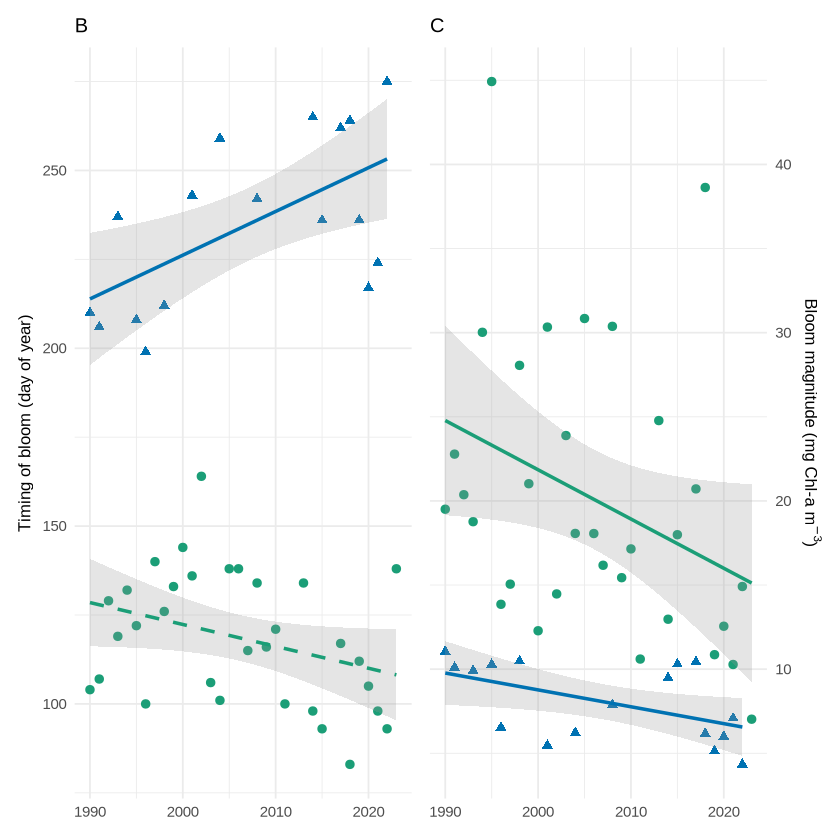

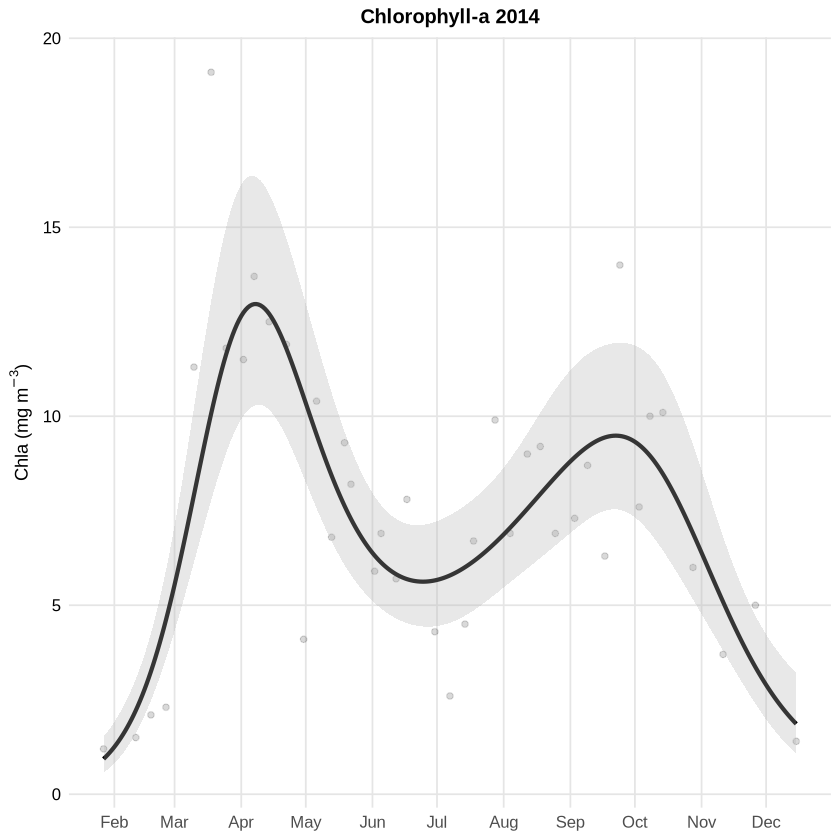

In [20]:
library(dplyr)
library(ggplot2)
library(patchwork)
library(tidyr)

# Color-blind friendly colors
spring_col <- "#1b9e77"  
fall_col <- "#0072B2"    

# ------------------------------
# Reuse GAM results created in Cell 14
# ------------------------------
# Read saved prediction-grid list at the beginning
pred_grid_rds <- paste0(processed_data_dir, "/pred_grid_list_model1.rds")
pred_grid_list_model1 <- readRDS(pred_grid_rds)

pheno_output <- read.csv(paste(wd_path, "/processed_data/", "pheno_output.csv", sep = ""))
model_performance <- read.csv(paste(wd_path, "/processed_data/", "model_performance_by_year.csv", sep = ""))

input_df <- read.csv(paste(wd_path, "/processed_data/", "Jetty_HWseries.csv", sep = ""),
                       fileEncoding = "UTF-8", na.strings = c("", "NA"), header = TRUE)
input_df$timestamp <- lubridate::ymd_hms(input_df$timestamp)
input_df$Day <- lubridate::yday(input_df$timestamp)
input_df$Year <- lubridate::year(input_df$timestamp)
input_df$date <- as.Date(input_df$timestamp)
input_df <- input_df %>% filter(Year >= 1990 & Year <= 2023, Year != 2016)

# Ensure logical column after CSV import
# pheno_output$use_for_peak_analysis <- as.logical(pheno_output$use_for_peak_analysis)

# Primary subset for trend models (R2 >= threshold from Cell 14)
#pheno_peak <- pheno_output %>%
#  filter(use_for_peak_analysis %in% TRUE)

pheno_peak <- pheno_output %>% filter(Year != 2012)

# Panel B: Bloom Timing
panel_B <- ggplot(pheno_peak, aes(x = Year)) +
  geom_point(aes(y = t_Spr_peak), size = 2, pch = 19, color = spring_col) +
  geom_point(aes(y = t_2nd_peak), size = 2, pch = 17, color = fall_col) +
  geom_smooth(data = pheno_peak, aes(y = t_Spr_peak), method = "lm", se = TRUE, alpha = 0.25, color = spring_col, linetype = "dashed") +
  geom_smooth(data = pheno_peak, aes(y = t_2nd_peak), method = "lm", se = TRUE, alpha = 0.25, color = fall_col, linetype = "solid") +
  labs(
    y = "Timing of bloom (day of year)",
    x = NULL,
    title = "B"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(size = 12, hjust = 0),
    axis.title = element_text(size = 10),
    axis.text = element_text(size = 9),
    legend.position = "top"
  )

# Panel C: Bloom Magnitude
panel_C <- ggplot(pheno_peak, aes(x = Year)) +
  geom_point(aes(y = Chl_Spr_peak), size = 2, pch = 19, color = spring_col) +
  geom_point(aes(y = Chl_2nd_peak), size = 2, pch = 17, color = fall_col) +
  geom_smooth(data = pheno_peak, aes(y = Chl_Spr_peak), method = "lm", se = TRUE, alpha = 0.25, color = spring_col, linetype = "solid") +
  geom_smooth(data = pheno_peak, aes(y = Chl_2nd_peak), method = "lm", se = TRUE, alpha = 0.25, color = fall_col, linetype = "solid") +
  scale_y_continuous(position = "right") +
  labs(
    y = expression("Bloom magnitude (mg Chl-a m"^{-3}*")"),
    x = NULL,
    title = "C"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(size = 12, hjust = 0),
    axis.title = element_text(size = 10),
    axis.text = element_text(size = 9),
    legend.position = "top"
  )

# Linear model summaries from primary subset
lm_spr_timing <- lm(t_Spr_peak ~ Year, data = pheno_peak)
cat("\n=== Spring Bloom Timing (Primary set) ===\n")
summary(lm_spr_timing)

lm_2nd_timing <- lm(t_2nd_peak ~ Year, data = pheno_peak)
cat("\n=== Secondary Bloom Timing (Primary set) ===\n")
summary(lm_2nd_timing)

lm_spr_mag <- lm(Chl_Spr_peak ~ Year, data = pheno_peak)
cat("\n=== Spring Bloom Magnitude (Primary set) ===\n")
summary(lm_spr_mag)

lm_2nd_mag <- lm(Chl_2nd_peak ~ Year, data = pheno_peak)
cat("\n=== Secondary Bloom Magnitude (Primary set) ===\n")
summary(lm_2nd_mag)

cat("\n=== Model confidence counts (all years) ===\n")
print(table(pheno_output$model_confidence, useNA = "ifany"))
cat("\nYears in primary set:", nrow(pheno_peak), "of", nrow(pheno_output), "\n")

combined_plot <- panel_B | panel_C
combined_plot

# Save plot
ggsave(filename = paste(graph_dir,"Phenology.png",sep=""),
       plot = combined_plot,
      width = 10,
       height = 6,
       dpi = 600)

# ------------------------------
# Single-year Chla plot from Cell 14 fitted GAM
# ------------------------------
pred_grid_all <- bind_rows(pred_grid_list_model1, .id = "Year") %>%
  mutate(Year = as.integer(Year))

month_days <- c(1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335)
chla_color <- "black"
chla_ribbon <- "grey70"

create_chla_plot <- function(year_val, obs_data, pred_data) {
  chl_obs <- obs_data %>% filter(Year == year_val)
  chl_pred <- pred_data %>% filter(Year == year_val)

  if (nrow(chl_pred) == 0) return(NULL)

  ggplot() +
    xlim(1, 365) +
    geom_point(
      data = chl_obs,
      aes(x = Day, y = Chl),
      color = chla_color,
      alpha = 0.15,
      size = 1.5
    ) +
    geom_line(
      data = chl_pred,
      aes(x = Day, y = Chl),
      color = chla_color,
      linewidth = 1.2
    ) +
    geom_ribbon(
      data = chl_pred,
      aes(x = Day, ymin = Chl_lower, ymax = Chl_upper),
      fill = chla_ribbon,
      alpha = 0.3
    ) +
    scale_x_continuous(
      breaks = month_days,
      labels = month.abb
    ) +
    scale_y_continuous(
      name = expression("Chla (mg m"^{-3}*")")
    ) +
    labs(title = paste("Chlorophyll-a", year_val)) +
    theme_minimal() +
    theme(
      axis.title.x = element_blank(),
      axis.title.y.left = element_text(size = 11, face = "bold", color = chla_color),
      axis.text.y.left = element_text(size = 10, color = chla_color),
      axis.text.x = element_text(size = 10),
      plot.title = element_text(size = 12, face = "bold", hjust = 0.5),
      panel.grid.major = element_line(color = "gray90"),
      panel.grid.minor = element_blank()
    )
}

# Example single-year Chla plot
year_val <- 2014
p_chla <- create_chla_plot(year_val = year_val, obs_data = input_df, pred_data = pred_grid_all)
p_chla

# Optional save
filename <- paste0("Chla_", year_val, ".png")
#ggsave(
#   filename = file.path(graph_dir, filename),
#   plot = p_chla,
#   device = "png",
#   width = 5,
#   height = 4,
#   units = "in",
#   dpi = 600,
#   bg = "white"
#)

# Figure 5. Biomass, PP and mu (2012-2023)
bar plots 

In [15]:
# metadata: update the graph and analysis to focus on the phytoplankton growth period (May-Sept)

require(ggplot2)
require(lubridate)
require(dplyr)
require(mgcv)  # For GAM models
library(patchwork)

# Load and prepare data
#PI_curve <- read.csv(paste(PI_output_dir, "output_JP_v2.csv", sep = "")) %>%
#  mutate(datum = ymd_hms(datum),
#         I_opt = P_max / alpha)
PI_curve <- read.csv(paste(PI_output_dir, "output_v2.csv", sep = ""))

Jetty_df <- read.csv(
  file = paste(wd_path, "/processed_data/", "Jetty_HWseries.csv", sep = ""),
  fileEncoding = "UTF-8",
  na.strings = c("", "NA"),
  header = TRUE
) %>%
  mutate(timestamp = ymd_hms(timestamp))

# Merge datasets
PI_Jetty <- merge(PI_curve, Jetty_df, by.x = "HWcode", by.y = "SampleID") %>%
  mutate(Date = as.Date(datum),
         day_of_year = yday(datum),
         DIN = NH4 + NO3 + NO2)

#sumDay_PP_total <- read.csv(file = paste(wd_path, "/PP_cal/", "sumDay_PP_JP.csv", sep = "")) %>%
  #mutate(date = dmy(as.character(date)))
sumDay_PP_total <- read.csv(file = paste(wd_path, "/PP_cal/", "sumDay_PP.csv", sep = "")) %>%
  mutate(date = dmy(as.character(date)))

sumDay_PP_total <- sumDay_PP_total %>% filter(month(date) >= 5 & month(date) <= 9 & year(date) <= 2023) 
sumYear_PP_total <- aggregate(sumDay_PP_total$daily_PP, by = list(year(sumDay_PP_total$date)), FUN = sum)
names(sumYear_PP_total) <- c("Year", "PP_sumYear")

HW_PP <- merge(PI_Jetty, sumDay_PP_total, by.x = "Date", by.y = "date")

sumDay_PP_total$date <- ymd(sumDay_PP_total$date)
sumDay_PP_total$doy <- yday(sumDay_PP_total$date)

sumDay_PP_total$daily_PP[sumDay_PP_total$daily_PP <= 0] <- 0.001

Nut_Light_limitation_df <- read.csv(paste(PP_cal_dir, "Nut_Light_limitation_Jetty40.csv", sep = ""))
Nut_Light_limitation_df$Lim_Nut <- factor(Nut_Light_limitation_df$Lim_Nut, levels = c("DIN", "DP", "DSi"))
Nut_Light_limitation_df$date <- Nut_Light_limitation_df$date %>% as.Date()


# ==================== MERGE DATA ====================
df_combined <- merge(
  PI_Jetty[, c("Date", "Chl")],
  Nut_Light_limitation_df[, c("date", "mu")],
  by.x = "Date", by.y = "date",
  all = TRUE
) %>%
  mutate(Year = year(Date))

df_combined$month <- month(df_combined$Date)

# Filter for phytoplankton growth period (May-Sept)
df_combined <- df_combined %>%
  filter(month >= 5 & month <= 9)

# Annual means and SD for biomass and growth rate bars
df_yearly <- df_combined %>%
  group_by(Year) %>%
  summarise(
    Chl_mean = mean(Chl, na.rm = TRUE),
    Chl_sd = sd(Chl, na.rm = TRUE),
    mu_mean = mean(mu, na.rm = TRUE),
    mu_sd = sd(mu, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  filter(!is.na(Year), !is.nan(Chl_mean), !is.nan(mu_mean))

year_breaks <- sort(unique(c(sumYear_PP_total$Year, df_yearly$Year)))

head(df_combined)


,Date,Chl,mu,Year,month
,<date>,<dbl>,<dbl>,<dbl>,<dbl>
1,2012-05-07,12.488,0.4270293,2012,5
2,2012-05-23,5.859,0.3322409,2012,5
3,2012-06-05,11.414,0.3472128,2012,6
4,2012-06-19,2.120,0.7995522,2012,6
5,2012-06-25,2.728,1.0879560,2012,6
6,2012-07-04,NA,0.4629963,2012,7


              Metric       Slope      P_value R_squared   Pred_2012   Pred_2023
1        Growth rate  0.03951618 3.533575e-07 0.1159104   0.2569751   0.6916531
2 Primary production  4.89869447 2.129758e-01 0.1503508 119.3357878 173.2214270
3      Chl-a biomass -0.55923969 1.754442e-05 0.0846364  10.9463086   4.7946720
  Percent_change_2012_2023                   Unit
1                169.15178          d^-1 per year
2                 45.15463      g C m^-2 per year
3                -56.19827 mg Chl-a m^-3 per year


              Metric       Slope      P_value R_squared   Pred_2012   Pred_2023
1        Growth rate  0.03951618 3.533575e-07 0.1159104   0.2569751   0.6916531
2 Primary production  4.89869447 2.129758e-01 0.1503508 119.3357878 173.2214270
3      Chl-a biomass -0.55923969 1.754442e-05 0.0846364  10.9463086   4.7946720
  Percent_change_2012_2023                   Unit
1                169.15178          d^-1 per year
2                 45.15463      g C m^-2 per year
3                -56.19827 mg Chl-a m^-3 per year


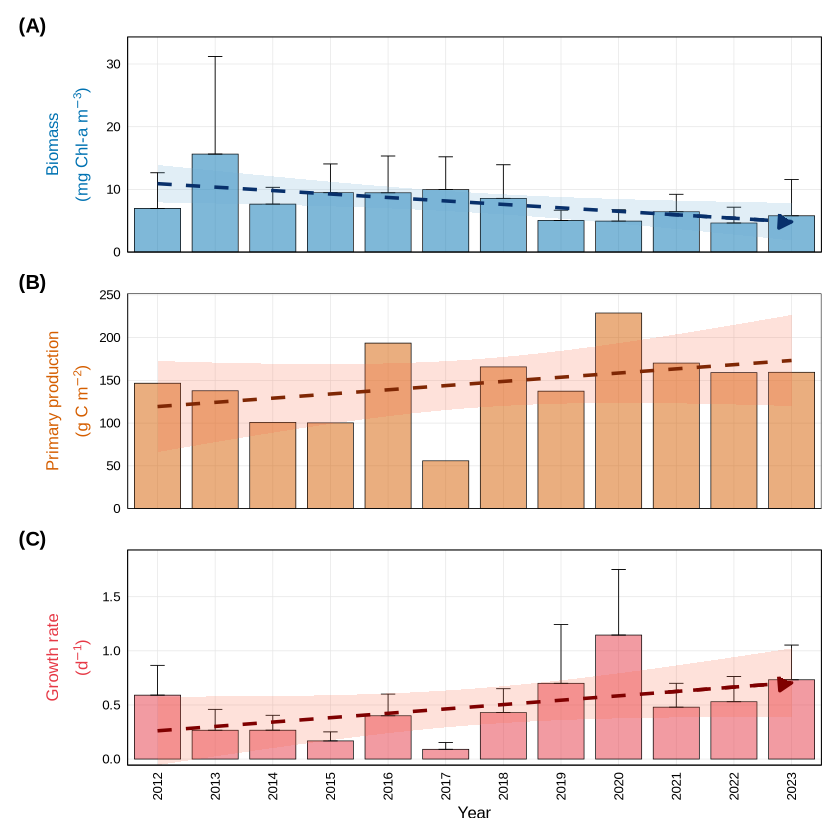

In [21]:
# metadata: update the graph and analysis to focus on the phytoplankton growth period (May-Sept)

require(ggplot2)
require(lubridate)
require(dplyr)
require(mgcv)  # For GAM models
library(patchwork)

# Load and prepare data
#PI_curve <- read.csv(paste(PI_output_dir, "output_JP_v2.csv", sep = "")) %>%
#  mutate(datum = ymd_hms(datum),
#         I_opt = P_max / alpha)
PI_curve <- read.csv(paste(PI_output_dir, "output_v2.csv", sep = ""))

Jetty_df <- read.csv(
  file = paste(wd_path, "/processed_data/", "Jetty_HWseries.csv", sep = ""),
  fileEncoding = "UTF-8",
  na.strings = c("", "NA"),
  header = TRUE
) %>%
  mutate(timestamp = ymd_hms(timestamp))

# Merge datasets
PI_Jetty <- merge(PI_curve, Jetty_df, by.x = "HWcode", by.y = "SampleID") %>%
  mutate(Date = as.Date(datum),
         day_of_year = yday(datum),
         DIN = NH4 + NO3 + NO2)

#sumDay_PP_total <- read.csv(file = paste(wd_path, "/PP_cal/", "sumDay_PP_JP.csv", sep = "")) %>%
  #mutate(date = dmy(as.character(date)))
sumDay_PP_total <- read.csv(file = paste(wd_path, "/PP_cal/", "sumDay_PP.csv", sep = "")) %>%
  mutate(date = dmy(as.character(date)))

sumDay_PP_total <- sumDay_PP_total %>% filter(month(date) >= 5 & month(date) <= 9 & year(date) <= 2023) 
sumYear_PP_total <- aggregate(sumDay_PP_total$daily_PP, by = list(year(sumDay_PP_total$date)), FUN = sum)
names(sumYear_PP_total) <- c("Year", "PP_sumYear")

HW_PP <- merge(PI_Jetty, sumDay_PP_total, by.x = "Date", by.y = "date")

sumDay_PP_total$date <- ymd(sumDay_PP_total$date)
sumDay_PP_total$doy <- yday(sumDay_PP_total$date)

sumDay_PP_total$daily_PP[sumDay_PP_total$daily_PP <= 0] <- 0.001

Nut_Light_limitation_df <- read.csv(paste(PP_cal_dir, "Nut_Light_limitation_Jetty40.csv", sep = ""))
Nut_Light_limitation_df$Lim_Nut <- factor(Nut_Light_limitation_df$Lim_Nut, levels = c("DIN", "DP", "DSi"))
Nut_Light_limitation_df$date <- Nut_Light_limitation_df$date %>% as.Date()


# ==================== MERGE DATA ====================
df_combined <- merge(
  PI_Jetty[, c("Date", "Chl")],
  Nut_Light_limitation_df[, c("date", "mu")],
  by.x = "Date", by.y = "date",
  all = TRUE
) %>%
  mutate(Year = year(Date))

df_combined$month <- month(df_combined$Date)

# Filter for phytoplankton growth period (May-Sept)
df_combined <- df_combined %>%
  filter(month >= 5 & month <= 9)

# Annual means and SD for biomass and growth rate bars
df_yearly <- df_combined %>%
  group_by(Year) %>%
  summarise(
    Chl_mean = mean(Chl, na.rm = TRUE),
    Chl_sd = sd(Chl, na.rm = TRUE),
    mu_mean = mean(mu, na.rm = TRUE),
    mu_sd = sd(mu, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  filter(!is.na(Year), !is.nan(Chl_mean), !is.nan(mu_mean))

year_breaks <- sort(unique(c(sumYear_PP_total$Year, df_yearly$Year)))

# Set consistent theme elements for all plots
pub_theme <- theme_minimal(base_size = 10) +
  theme(
    text = element_text(family = "Arial", color = "black"),
    panel.grid.major = element_line(color = "grey90", linewidth = 0.2),
    panel.grid.minor = element_blank(),
    panel.border = element_rect(fill = NA, color = "black", linewidth = 0.3),
    axis.title = element_text(size = 10, face = "plain"),
    axis.text = element_text(size = 8, color = "black"),
    axis.line = element_line(color = "black", linewidth = 0.2),
    plot.margin = unit(c(2, 2, 2, 2), "mm"),
    plot.tag = element_text(face = "bold", size = 12),  # For A, B, C labels
    legend.position = "none"
  )

# ==================== PANEL A: ANNUAL PRIMARY PRODUCTION (HISTOGRAM/BARS) ====================
PP_ts <- ggplot(sumYear_PP_total, aes(x = Year, y = PP_sumYear * 1e-3)) +
  geom_col(width = 0.8, fill = "#D55E00", color = "black", linewidth = 0.2) +
  # geom_smooth(method = "lm", formula = y ~ x, se = FALSE, color = "#7F2704", linewidth = 0.5) +
  labs(
    y = expression(atop("Primary production", "(g C m"^{-2}*")")),
    x = NULL
  ) +
  scale_x_continuous(
    breaks = year_breaks,
    labels = year_breaks,
    expand = expansion(mult = c(0.01, 0.01))
  ) +
  scale_y_continuous(
    expand = expansion(mult = c(0, 0.1)),
    limits = c(0, NA)
  ) +
  pub_theme +
  theme(
    axis.text.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.title.y = element_text(color = "#D55E00", size = 10)
  )

PP_ts_ci <- PP_ts
PP_ts_ci$layers[[1]]$aes_params$alpha <- 0.5
PP_ts_ci$layers[[2]] <- geom_smooth(
  data = sumYear_PP_total,
  aes(x = Year, y = PP_sumYear * 1e-3),
  method = "lm",
  formula = y ~ x,
  se = TRUE,
  color = "#7F2704",
  fill = "#FB6A4A",
  alpha = 0.2,
  linewidth = 1,
  linetype = "dashed"
)
# ==================== PANEL B: BIOMASS (CHL-A) BAR PLOT BY YEAR ====================
Chla_ts <- ggplot(df_yearly, aes(x = Year, y = Chl_mean)) +
  geom_col(width = 0.8, fill = "#0072B2", color = "black", alpha = 0.75, linewidth = 0.2) +
  geom_errorbar(
    aes(
      #ymin = pmax(Chl_mean - Chl_sd, 0),
      ymin = Chl_mean,
      ymax = Chl_mean + Chl_sd
    ),
    width = 0.25,
    linewidth = 0.25,
    color = "black",
    na.rm = TRUE
  ) +
  geom_smooth(method = "lm", formula = y ~ x, se = FALSE, color = "#08306B", linewidth = 0.5) +
  labs(
    y = expression(atop("Biomass", "(mg Chl-a m"^{-3}*")")),
    x = NULL
  ) +
  scale_x_continuous(
    breaks = year_breaks,
    labels = year_breaks,
    expand = expansion(mult = c(0.01, 0.01))
  ) +
  scale_y_continuous(
    expand = expansion(mult = c(0, 0.1)),
    limits = c(0, NA)
  ) +
  pub_theme +
  theme(
    axis.text.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.title.y = element_text(color = "#0072B2", size = 10)
  )

# Add 95% confidence intervals to trend lines from Cell 12
Chla_ts_ci <- Chla_ts
Chla_ts_ci$layers[[1]]$aes_params$alpha <- 0.5
Chla_ts_ci$layers[[3]] <- geom_smooth(
  method = "lm",
  formula = y ~ x,
  se = TRUE,
  color = "#08306B",
  fill = "#6BAED6",
  alpha = 0.2,
  linewidth = 1,
  linetype = "dashed"
)


# ==================== PANEL C: GROWTH RATE BAR PLOT BY YEAR ====================



Growth_ts <- ggplot(df_yearly, aes(x = Year, y = mu_mean)) +
  geom_col(width = 0.8, fill = "#E63946", color = "black", alpha = 0.75, linewidth = 0.2) +
  geom_errorbar(
    aes(
      #ymin = mu_mean - mu_sd,
      ymin = mu_mean,
      ymax = mu_mean + mu_sd
    ),
    width = 0.25,
    linewidth = 0.25,
    color = "black",
    na.rm = TRUE
  ) +
  geom_smooth(method = "lm", formula = y ~ x, se = FALSE, color = "#7F0000", linewidth = 0.5) +
  labs(
    y = expression(atop("Growth rate", "(d"^{-1}*")")),
    x = "Year"
  ) +
  scale_x_continuous(
    breaks = year_breaks,
    labels = year_breaks,
    expand = expansion(mult = c(0.01, 0.01))
  ) +
  scale_y_continuous(
    expand = expansion(mult = c(0, 0.1))
  ) +
  pub_theme +
  theme(
    axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1),
    axis.title.y = element_text(color = "#E63946", size = 10)
  )

Growth_ts_ci <- Growth_ts
Growth_ts_ci$layers[[1]]$aes_params$alpha <- 0.5
Growth_ts_ci$layers[[3]] <- geom_smooth(
  method = "lm",
  formula = y ~ x,
  se = TRUE,
  color = "#7F0000",
  fill = "#FB6A4A",
  alpha = 0.2,
  linewidth = 1,
  linetype = "dashed"
)

add_trend_arrow <- function(plot_obj, data, response, color) {
  model <- lm(reformulate("Year", response = response), data = data)
  arrow_x_end <- max(data$Year, na.rm = TRUE)
  arrow_x_start <- arrow_x_end - 2.2
  arrow_y_start <- predict(model, newdata = data.frame(Year = arrow_x_start))
  arrow_y_end <- predict(model, newdata = data.frame(Year = arrow_x_end))

  plot_obj +
    annotate(
      "segment",
      x = arrow_x_start,
      xend = arrow_x_end,
      y = arrow_y_start,
      yend = arrow_y_end,
      color = color,
      linewidth = 1,
      linetype = "dashed",
      arrow = arrow(length = unit(0.3, "cm"), type = "closed")
    )
}

Chla_ts_ci <- add_trend_arrow(Chla_ts_ci, df_yearly, "Chl_mean", "#08306B")
Growth_ts_ci <- add_trend_arrow(Growth_ts_ci, df_yearly, "mu_mean", "#7F0000")

# ==================== COMBINE ALL THREE PANELS WITH PATCHWORK ====================
combined_plot_ci <- Chla_ts_ci / PP_ts_ci / Growth_ts_ci +
  plot_annotation(tag_levels = "A", tag_prefix = "(", tag_suffix = ")") &
  theme(
    plot.tag = element_text(face = "bold", hjust = 0, vjust = 1)
  )

combined_plot_ci


# some statistics:
Nut_Light_limitation_df$post2018 <- ifelse(Nut_Light_limitation_df$year > 2018, "Y", "N")
#lm(mu ~ post2018, data = Nut_Light_limitation_df) %>% summary
#aov(mu ~ post2018, data = Nut_Light_limitation_df) %>% summary

#range(sumYear_PP_total$PP_sumYear, na.rm = TRUE)
#range(df_yearly$mu_mean, na.rm=TRUE)
#range(df_yearly$Chl_mean, na.rm=TRUE)

lm_pp_slope <- lm(I(PP_sumYear * 1e-3) ~ Year, data = sumYear_PP_total)
lm_chla_slope <- lm(Chl ~ Year, data = df_combined)
lm_mu_slope <- lm(mu ~ Year, data = df_combined)

extract_slope_stats <- function(model, metric_name, slope_unit) {
  coeff_tab <- summary(model)$coefficients
  pred_2012 <- unname(predict(model, newdata = data.frame(Year = 2012)))
  pred_2023 <- unname(predict(model, newdata = data.frame(Year = 2023)))
  pct_change <- ifelse(
    abs(pred_2012) < .Machine$double.eps,
    NA_real_,
    (pred_2023 - pred_2012) / pred_2012 * 100
  )

  data.frame(
    Metric = metric_name,
    Slope = unname(coeff_tab["Year", "Estimate"]),
    P_value = unname(coeff_tab["Year", "Pr(>|t|)"]),
    R_squared = unname(summary(model)$r.squared),
    Pred_2012 = pred_2012,
    Pred_2023 = pred_2023,
    Percent_change_2012_2023 = pct_change,
    Unit = slope_unit,
    row.names = NULL
  )
}

slope_stats <- bind_rows(
  extract_slope_stats(lm_mu_slope, "Growth rate", "d^-1 per year"),
  extract_slope_stats(lm_pp_slope, "Primary production", "g C m^-2 per year"),
  extract_slope_stats(lm_chla_slope, "Chl-a biomass", "mg Chl-a m^-3 per year")
)

print(slope_stats)

# ==================== SAVE OUTPUT ====================
#ggsave(
#  filename = paste0(graph_dir, "PrimaryProduction_biomass_growth_Fig5.pdf"),
#  plot = combined_plot_ci,
#  device = grDevices::cairo_pdf,
#  width = 180,
#  height = 150,
#  units = "mm",
#  bg = "white"
# )

# Figure 6. Limiting factor

Warning message:
“Duplicated `override.aes` is ignored.”
Warning message:
“Duplicated `override.aes` is ignored.”


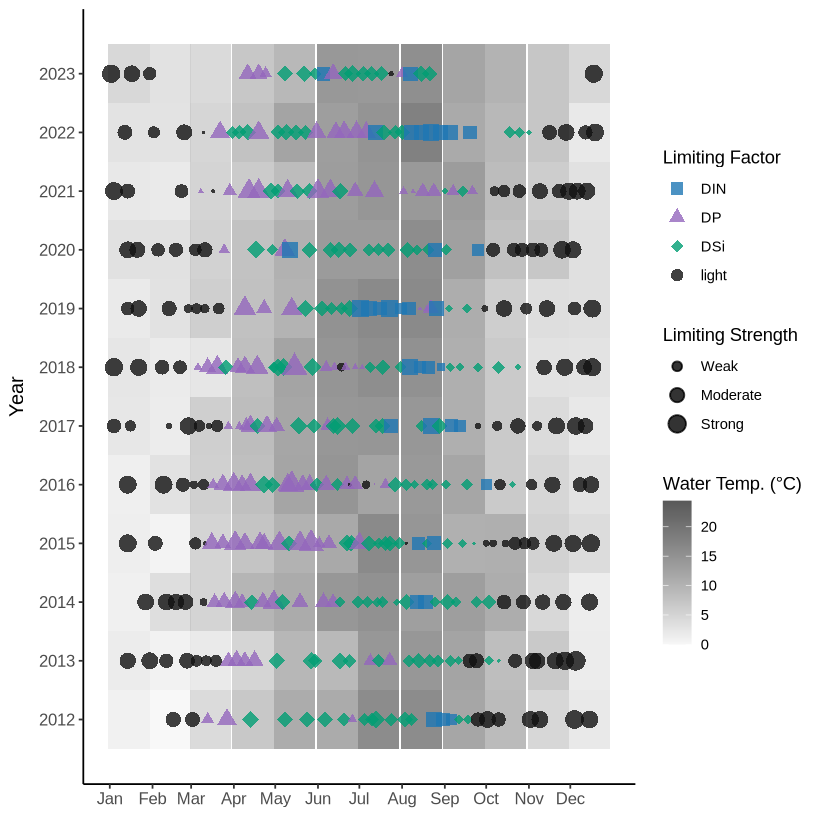

In [ ]:
library(ggplot2)
library(scales)
library(dplyr)

# Define approximate day-of-year positions for month labels
month_days <- c(1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335) # start of each month

# Define limiting-factor colors
lim_colors <- c(#"light" = "#00FFFF",
                "light" = "#111111",
                "DIN"   = "#1F77B4",
                "DP"    = "#9467BD",
                "DSi"   = "#009E73")

# Define shapes
shape_mapping <- c("light" = 16,  # circle
                   "DIN"   = 15,  # square
                   "DP"    = 17,  # triangle
                   "DSi"   = 18)  # diamond

Jetty_df = read.csv(file=paste(wd_path,"/processed_data/","Jetty_HWseries.csv",sep=""), fileEncoding = "UTF-8", na.strings=c("", "NA"), header=TRUE)
Jetty_df$timestamp <- Jetty_df$timestamp%>%ymd_hms()
Jetty_df$Year <- year(Jetty_df$timestamp)
Jetty_df$doy <- yday(Jetty_df$timestamp)
Jetty_df$month <- month(Jetty_df$timestamp)

Jetty_temp_doy <- Jetty_df %>% filter(Year >= 2012 & Year <= 2023) %>%
  mutate(
    day_of_year = c(15, 45, 74, 105, 135, 166, 
                    196, 227, 258, 288, 319, 349)[month]
  )

Nut_Light_limitation_df <- read.csv(paste(PP_cal_dir,"Nut_Light_limitation_Jetty40.csv",sep=""))
Nut_Light_limitation_df$Lim_Nut <- factor(Nut_Light_limitation_df$Lim_Nut, levels=c("DIN","DP","DSi"))

# Create the plot
p_cloern <- ggplot(Nut_Light_limitation_df, aes(x = day_of_year, y = year)) +
  # Temperature background as red gradient
  geom_tile(data = Jetty_temp_doy,
            aes(x = day_of_year, y = Year, fill = T),
            height = 1, width = 30,
            alpha = 0.3,
            inherit.aes = FALSE) +
  # geom_contour(data = Jetty_temp_doy,
  #              aes(x = day_of_year, y = Year, z = T),
  #              bins = 8,
  #              color = "black",
  #              #linewidth = 0.3,
  #              alpha = 0.6,
  #              #linetype = "dashed",
  #              inherit.aes = FALSE) +
  #scale_fill_gradient(name = "Water Temp. (°C)", low = "mistyrose", high = "red") +
  scale_fill_gradient(name = "Water Temp. (°C)", low = "grey97", high = "grey35") +

  # Limitation points
  geom_point(aes(shape = limiting_factor,
                 color = limiting_factor,
                 size = line_thickness),
             alpha = 0.8,
             stroke = 0.8) +
  # Apply the requested colors and shapes
  scale_color_manual(
    name = "Limiting Factor",
    values = lim_colors,
    guide = guide_legend(override.aes = list(size = 3))) +
  scale_shape_manual(
    name = "Limiting Factor",
    values = shape_mapping,
    guide = guide_legend(override.aes = list(size = 3))) +
  # Other manuscript-ready formatting
  theme_classic() +
  theme(legend.position = "right",
        axis.title = element_text(size = 12),
        axis.text = element_text(size = 10)) +
  labs(x = "", y = "Year") +
 # Axis formatting
  scale_x_continuous(
    breaks = month_days,
    labels = month.abb
  ) +
  scale_y_continuous(
    breaks = 2012:2023 
  ) +
  scale_size_continuous(
    name = "Limiting Strength",
    range = c(0, 5),  # Slightly increased size range
    breaks = c(1, 2.5, 4),
    labels = c("Weak", "Moderate", "Strong")
  )

p_cloern

# Save as high-quality single-column figure
#ggsave(
#   filename = file.path(graph_dir, "FigX_Cloern_Limitations.png"),
#   plot = p_cloern,
#   device = "png",
#   width = 7,       # Standard single-column width (inches)
#   height = 7,        # Adjusted height for better proportions
#   units = "in",
#   dpi = 600,         # Publication quality
#   bg = "white"
#)

# Figure 7. LT light trends

REMARKS
⦁	Based upon Figure 4B, the spring bloom occurred between DOY 60 (beginning of March) and DOY 140 (mid-May)
⦁	Based upon Figure 6, the shift in spring from light- to nutrient-limitation occurred in March
⦁	You cannot use averages of Secchi depth, only for attenuation coefficients
⦁	Would, therefore, suggest to focus Figure 7 on this period (March-April) to explore if light conditions show a long-term trend
⦁	And then present 3 panels, being (A) Mean insolation (kW m-2 day-1), (B) Attenuation coefficient during sampling (m-1), and (C) Mean light conditions at 1m depth during sampling (PAR m-2 day-1), including trend analyses for all panels.

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


                                  Metric       Slope     P_value R_squared
1             Surface PAR (Mar-Apr mean)  0.12951518 0.003865770 0.2326563
2 Attenuation coefficient (Mar-Apr mean) -0.02307017 0.002150427 0.2582779
3      Light at 1 m depth (Mar-Apr mean)  0.06551888 0.001147983 0.2849738
  Pred_1990 Pred_2023 Percent_change_1990_2023                 Unit
1 23.883575 28.157575                 17.89515 E m^-2 d^-1 per year
2  2.577639  1.816324                -29.53538        m^-1 per year
3  2.783660  4.945783                 77.67197 E m^-2 d^-1 per year


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


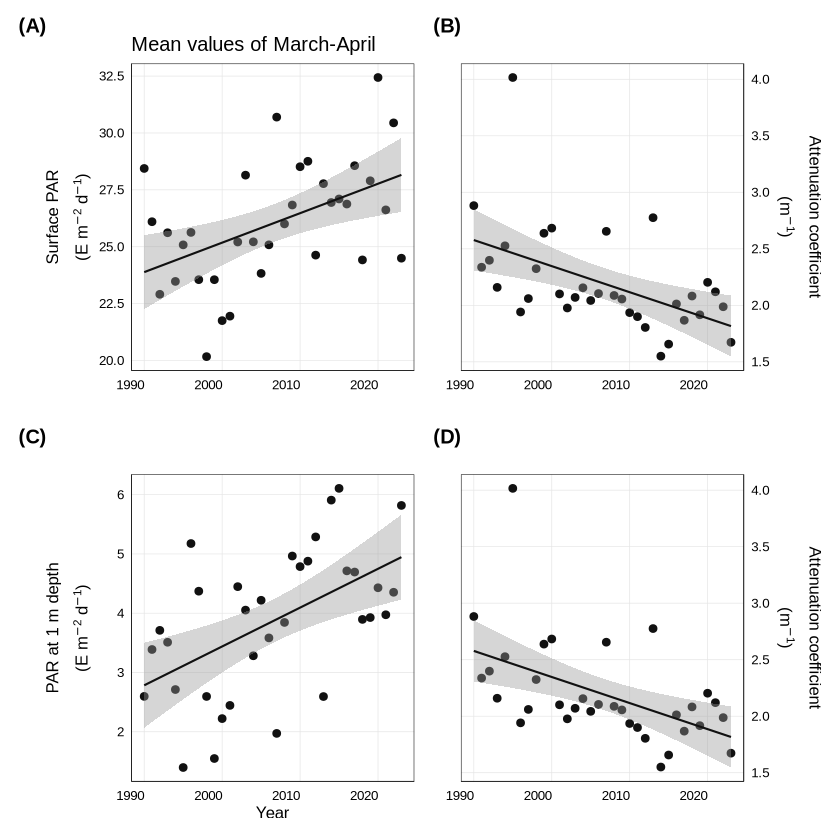

In [12]:
# Calculate and plot the annual trend of mean insolation (March-April)
library(dplyr)
library(ggplot2)
library(lubridate)
library(patchwork)

dailyQ_KNMI_filepath <- paste(wd_path,"/rawdata/","d_Q_235.txt",sep="") # daily global radiation (J/cm2) from KNMI de Kooy station (1990-2023)
dailyQ_deKooy <- read.table(dailyQ_KNMI_filepath, header = TRUE, sep = ",")
dailyQ_deKooy$YYYYMMDD <- ymd(dailyQ_deKooy$YYYYMMDD)
dailyQ_deKooy$doy <- yday(dailyQ_deKooy$YYYYMMDD)
dailyQ_deKooy$Year <- year(dailyQ_deKooy$YYYYMMDD)
dailyQ_deKooy$Month <- month(dailyQ_deKooy$YYYYMMDD)

dailyQ_deKooy <- dailyQ_deKooy[, c("YYYYMMDD", "doy", "Year", "Month", "Q")] %>% na.omit()
dailyQ_deKooy <- dailyQ_deKooy[which(dailyQ_deKooy$Year >= 1990 & dailyQ_deKooy$Year <= 2023), ]

Jetty_df <- read.csv(
  file = paste(wd_path, "/processed_data/", "Jetty_HWseries.csv", sep = ""),
  fileEncoding = "UTF-8",
  na.strings = c("", "NA"),
  header = TRUE
)
Jetty_df$timestamp <- Jetty_df$timestamp %>% ymd_hms()

Jetty_df_1990_2023 <- Jetty_df[which(Jetty_df$Year >= 1990 & Jetty_df$Year <= 2023), ]

Jetty_df <- Jetty_df[which(Jetty_df$Year >= 1990 & Jetty_df$Year <= 2023), ]
Jetty_df <- Jetty_df[, c("timestamp", "SecchiDepth", "Kd_Secci")] %>% na.omit()
Jetty_df$date <- as.Date(Jetty_df$timestamp)

Jetty_df_1990_2023$date <- as.Date(Jetty_df_1990_2023$timestamp)
Jetty_df_1990_2023$Month <- month(Jetty_df_1990_2023$date)
Jetty_df_1990_2023$Year <- year(Jetty_df_1990_2023$date)

Light_df <- merge(dailyQ_deKooy, Jetty_df, by.x = c("YYYYMMDD"), by.y = c("date"), all.y = TRUE) %>%
  filter(Year >= 1990 & Year <= 2023)

# Conversion from daily global radiation (J/cm2) to photon flux (E/m2/day)
par_fraction <- 0.45
surface_reflectance <- 0.07
jcm2_to_jm2 <- 1e4
uE_per_joule_PAR <- 4.66
uE_to_E <- 1e-6

dailyQ_deKooy$PAR_E_m2_day <- dailyQ_deKooy$Q * jcm2_to_jm2 * par_fraction * uE_per_joule_PAR * uE_to_E
Light_df$I_0 <- Light_df$Q * jcm2_to_jm2 * par_fraction * (1 - surface_reflectance) * uE_per_joule_PAR * uE_to_E
Light_df$I_z <- Light_df$I_0 * exp(-Light_df$Kd_Secci * 1) # light conditions at 1 m depth

# For each year, calculate mean surface PAR (E m-2 day-1) from March to April
mean_light <- dailyQ_deKooy %>%
  filter(Month %in% c(3, 4)) %>%
  group_by(Year) %>%
  summarize(
    Mean_PAR_E_m2_day = mean(PAR_E_m2_day, na.rm = TRUE),
    .groups = "drop"
  )

# For each year, calculate mean attenuation coefficients k from March to April
mean_Kd_Secci <- Jetty_df_1990_2023 %>%
  filter(Month %in% c(3, 4)) %>%
  group_by(Year) %>%
  summarize(
    mean_Kd = mean(Kd_Secci, na.rm = TRUE),
    .groups = "drop"
  )

# For each year, calculate mean light conditions at 1 m depth (E m-2 day-1) from March to April
mean_light_I_z <- Light_df %>%
  filter(Month %in% c(3, 4)) %>%
  group_by(Year) %>%
  summarize(
    Mean_Iz_E_m2_day = mean(I_z, na.rm = TRUE),
    .groups = "drop"
  )

# Theme aligned with other publication figures in this notebook
light_theme <- theme_minimal(base_size = 10) +
  theme(
    text = element_text(family = "Arial", color = "black"),
    panel.grid.major = element_line(color = "grey90", linewidth = 0.2),
    panel.grid.minor = element_blank(),
    panel.border = element_rect(fill = NA, color = "black", linewidth = 0.3),
    axis.title = element_text(size = 10, face = "plain"),
    axis.text = element_text(size = 8, color = "black"),
    axis.line = element_line(color = "black", linewidth = 0.2),
    plot.margin = unit(c(2, 2, 2, 2), "mm")
  )

# Plot the annual trend of surface PAR
p_mean_light <- ggplot(mean_light, aes(x = Year, y = Mean_PAR_E_m2_day)) +
  geom_point(color = "#111111", size = 1.8) +
  geom_smooth(method = "lm", se = TRUE, color = "#111111", linetype = "solid", linewidth = 0.6) +
  labs(
    title = "Mean values of March-April",
    x = "",
    y = expression(atop("Surface PAR", "(E m"^{-2}*" d"^{-1}*")"))
  ) +
  light_theme +
  scale_x_continuous(breaks = seq(1990, 2023, by = 10)) +
  theme(
    axis.text.x = element_text(angle = 0, vjust = 0.5, hjust = 1)
  )

# Plot the annual trend of mean attenuation coefficients k
p_Kd <- ggplot(mean_Kd_Secci, aes(x = Year, y = mean_Kd)) +
  geom_point(color = "#111111", size = 1.8) +
  geom_smooth(method = "lm", se = TRUE, color = "#111111", linetype = "solid", linewidth = 0.6) +
  scale_y_continuous(position = "right") +
  labs(
    title = "",
    x = "",
    y = expression(atop("Attenuation coefficient", "(m"^{-1}*")"))
  ) +
  light_theme +
  scale_x_continuous(breaks = seq(1990, 2023, by = 10)) +
  theme(
    axis.text.x = element_text(angle = 0, vjust = 0.5, hjust = 1),
    axis.title.y.left = element_blank(),
    axis.text.y.left = element_blank(),
    axis.ticks.y.left = element_blank(),
    axis.title.y.right = element_text(size = 10, face = "plain"),
    axis.text.y.right = element_text(size = 8, color = "black")
  )

# Plot the annual trend of mean light conditions at 1 m depth
p_I_z <- ggplot(mean_light_I_z, aes(x = Year, y = Mean_Iz_E_m2_day)) +
  geom_point(color = "#111111", size = 1.8) +
  geom_smooth(method = "lm", se = TRUE, color = "#111111", linetype = "solid", linewidth = 0.6) +
  labs(
    x = "Year",
    y = expression(atop("PAR at 1 m depth", "(E m"^{-2}*" d"^{-1}*")"))
  ) +
  light_theme +
  scale_x_continuous(breaks = seq(1990, 2023, by = 10)) +
  theme(
    axis.text.x = element_text(angle = 0, vjust = 0.5, hjust = 1)
  )

# 2x2 layout with empty bottom-right panel
p_light_comb <- (p_mean_light + p_Kd) / (p_I_z + p_Kd) +
  plot_annotation(tag_levels = "A", tag_prefix = "(", tag_suffix = ")") &
  theme(plot.tag = element_text(face = "bold", hjust = 0, vjust = 1))

print(p_light_comb)

# Linear regression
lm_Qmean <- lm(Mean_PAR_E_m2_day ~ Year, data = mean_light)
lm_Kd <- lm(mean_Kd ~ Year, data = mean_Kd_Secci)
lm_Iz <- lm(Mean_Iz_E_m2_day ~ Year, data = mean_light_I_z)

extract_trend_stats <- function(model, metric_name, slope_unit) {
  coeff_tab <- summary(model)$coefficients
  pred_1990 <- unname(predict(model, newdata = data.frame(Year = 1990)))
  pred_2023 <- unname(predict(model, newdata = data.frame(Year = 2023)))
  pct_change <- ifelse(
    abs(pred_1990) < .Machine$double.eps,
    NA_real_,
    (pred_2023 - pred_1990) / pred_1990 * 100
  )

  data.frame(
    Metric = metric_name,
    Slope = unname(coeff_tab["Year", "Estimate"]),
    P_value = unname(coeff_tab["Year", "Pr(>|t|)"]),
    R_squared = unname(summary(model)$r.squared),
    Pred_1990 = pred_1990,
    Pred_2023 = pred_2023,
    Percent_change_1990_2023 = pct_change,
    Unit = slope_unit,
    row.names = NULL
  )
}

light_trend_stats <- bind_rows(
  extract_trend_stats(lm_Qmean, "Surface PAR (Mar-Apr mean)", "E m^-2 d^-1 per year"),
  extract_trend_stats(lm_Kd, "Attenuation coefficient (Mar-Apr mean)", "m^-1 per year"),
  extract_trend_stats(lm_Iz, "Light at 1 m depth (Mar-Apr mean)", "E m^-2 d^-1 per year")
)

print(light_trend_stats)

# ==================== SAVE OUTPUT ====================
ggsave(
  filename = file.path(graph_dir, "Light_trends_Fig7.pdf"),
  plot = p_light_comb,
  device = grDevices::cairo_pdf,
  width = 180,
  height = 150,
  units = "mm",
  bg = "white"
)

# Figure 8. Riverine nutrient loads trend

Warning message in scan(file = file, what = what, sep = sep, quote = quote, dec = dec, :
“number of items read is not a multiple of the number of columns”
Warning message in scan(file = file, what = what, sep = sep, quote = quote, dec = dec, :
“number of items read is not a multiple of the number of columns”
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


                         Metric      Slope      P_value R_squared Pred_1990
1            TIN load (Dec-Aug) -6.2433893 1.804976e-08 0.6704785 320.22391
2            TIP load (Dec-Aug) -0.5031454 1.050314e-07 0.6286730  17.95192
3             N:P ratio (molar)  1.6397728 5.223755e-08 0.6458376  33.80918
4 Autumn NH4+NO2 (Sep-Nov mean) -0.1850218 5.639789e-06 0.4908031  11.77594
   Pred_2023 Percent_change_1990_2023                   Unit
1 114.192062                -64.33993 ktonnes yr^-1 per year
2   1.348119                -92.49039 ktonnes yr^-1 per year
3  87.921688                160.05267    mol mol^-1 per year
4   5.670223                -51.84910       ug L^-1 per year


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


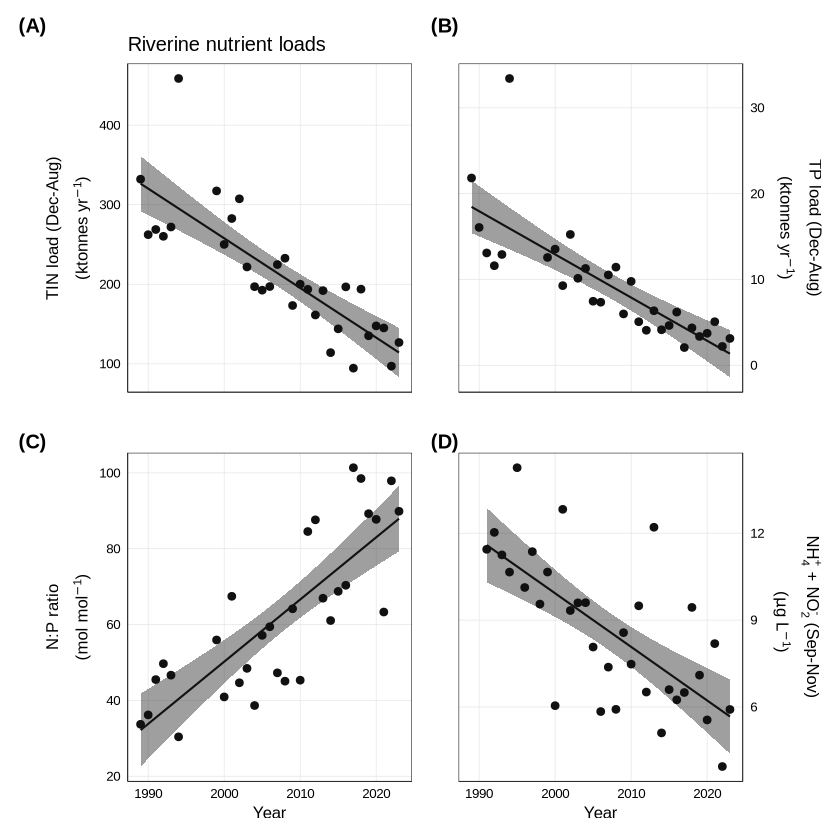

In [14]:

# Input data
library(mgcv)
library(ggplot2)
library(lubridate)
library(plotly)
library(dplyr)
library(pracma)
library(tidyverse)
library(lubridate)

Jetty_df = read.csv(file=paste(wd_path,"/processed_data/","Jetty_HWseries.csv",sep=""), fileEncoding = "UTF-8", na.strings=c("", "NA"), header=TRUE)
Jetty_df$timestamp <- Jetty_df$timestamp%>%ymd_hms()
Jetty_df$doy <- yday(Jetty_df$timestamp)
Jetty_df$Day <- yday(Jetty_df$timestamp)
Jetty_df$Year <- year(Jetty_df$timestamp)
Jetty_df$DIN <- Jetty_df$NH4 + Jetty_df$NO2 + Jetty_df$NO3



read_river_dat <- function(file, river_name) {
  
  df <- read.table(
    file,
    skip = 3,
    header = FALSE,
    stringsAsFactors = FALSE
  )
  
  colnames(df) <- c(
    "year", "month", "day",
    "discharge_m3s",
    "totalN_t_d", "nitrate_t_d", "ammonium_t_d", "DIN_t_d",
    "totalP_t_d", "phosphate_t_d", "silicate_t_d",
    "TALK_Mmol_d", "DIC_Mmol_d", "DOC_Mmol_d"
  )
  
  df %>%
    mutate(across(everything(), as.numeric)) %>%   # <-- key line
    mutate(
      date = make_date(year, month, day),
      river = river_name
    ) %>%
    mutate(across(everything(), ~ replace(., . < 0, NA)))
}

river_files <- c(
  haringvliet = paste0(wd_path, "/rawdata/lharingv.dat"),
  nieuw_waterweg = paste0(wd_path, "/rawdata/lnwaterw.dat"),
  nordzeekanaal = paste0(wd_path, "/rawdata/lnzkanal.dat"),
  lijssele = paste0(wd_path, "/rawdata/lijssele.dat"),
  lijsselw = paste0(wd_path, "/rawdata/lijsselw.dat")
)

river_daily <- imap_dfr(
  river_files,
  ~ read_river_dat(.x, .y)
)


# ============================================================================
# Figure 8. Riverine nutrient load trends (1990-2023)
# ============================================================================

library(dplyr)
library(ggplot2)
library(lubridate)
library(patchwork)

# Step 1: Annual loads (Dec prev year - Aug current year)
river_analysis <- river_daily %>%
  filter(river %in% c("haringvliet", "nieuw_waterweg", "lijssele", "lijsselw")) %>%
  mutate(water_year = if_else(month %in% 12, year + 1, year)) %>%
  filter(month %in% c(12, 1:8)) %>%
  group_by(water_year) %>%
  summarise(
    TN_load_t  = sum(totalN_t_d,   na.rm = TRUE),
    TP_load_t  = sum(totalP_t_d,   na.rm = TRUE),
    TSi_load_t = sum(silicate_t_d, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(
    TN_load_kt  = TN_load_t  / 1000,
    TP_load_kt  = TP_load_t  / 1000,
    TSi_load_kt = TSi_load_t / 1000
  ) %>%
  rename(year = water_year) %>%
  filter(year >= 1989, year <= 2023) %>%
  arrange(year)


# Step 2: Merge & exclude problem years
raw_analysis_df <- river_analysis %>%
  inner_join(chl_summer, by = "year") %>%
  arrange(year)

problem_years <- c(1995:1998)
analysis_df <- river_analysis %>%
  filter(!(year %in% problem_years)) %>%
  mutate(NP_ratio = (TN_load_kt / 14) / (TP_load_kt / 31))

# Autumn NH4 + NO2 (Sep-Nov) from Jetty data
autumn_NH4_NO2 <- Jetty_df %>%
  mutate(month = month(timestamp), year = year(timestamp), DIN_autumn = NH4 + NO2) %>%
  filter(month %in% 9:11) %>%
  group_by(year) %>%
  summarise(
    DIN_autumn_mean = mean(DIN_autumn, na.rm = TRUE),
    DIN_autumn_sd   = sd(DIN_autumn,   na.rm = TRUE),
    n_din = n(),
    .groups = 'drop'
  ) %>%
  filter(year >= 1989, year <= 2023) %>%
  arrange(year)

# Step 4: Fit linear models
model_tn_time    <- lm(TN_load_kt      ~ year, data = analysis_df)
model_tp_time    <- lm(TP_load_kt      ~ year, data = analysis_df)
model_np_time    <- lm(NP_ratio        ~ year, data = analysis_df)
model_autumn_DIN <- lm(DIN_autumn_mean ~ year, data = autumn_NH4_NO2)

# ============================================================================
# Publication theme (matching light trends figure)
# ============================================================================
nut_theme <- theme_minimal(base_size = 10) +
  theme(
    text             = element_text(family = "Arial", color = "black"),
    panel.grid.major = element_line(color = "grey90", linewidth = 0.2),
    panel.grid.minor = element_blank(),
    panel.border     = element_rect(fill = NA, color = "black", linewidth = 0.3),
    axis.title       = element_text(size = 10, face = "plain"),
    axis.text        = element_text(size = 8,  color = "black"),
    axis.line        = element_line(color = "black", linewidth = 0.2),
    plot.margin      = unit(c(2, 2, 2, 2), "mm")
  )

data_col   <- "#111111"
ribbon_col <- adjustcolor("#111111", alpha.f = 0.18)
xbreaks    <- seq(1990, 2023, by = 10)

# ============================================================================
# Individual panels
# ============================================================================
p_tn_time <- ggplot(analysis_df, aes(x = year, y = TN_load_kt)) +
  geom_point(color = data_col, size = 1.8) +
  geom_smooth(method = "lm", se = TRUE, color = data_col, linetype = "solid",
              linewidth = 0.6, fill = ribbon_col) +
  labs(
    title = "Riverine nutrient loads",
    x = "",
    y = expression(atop("TIN load" * " (Dec-Aug)", "(ktonnes yr"^{-1}*")"))
  ) +
  scale_x_continuous(breaks = xbreaks) +
  nut_theme +
  theme(axis.text.x = element_blank(), axis.ticks.x = element_blank())

p_tp_time <- ggplot(analysis_df, aes(x = year, y = TP_load_kt)) +
  geom_point(color = data_col, size = 1.8) +
  geom_smooth(method = "lm", se = TRUE, color = data_col, linetype = "solid",
              linewidth = 0.6, fill = ribbon_col) +
  scale_y_continuous(position = "right") +
  labs(
    title = "",
    x = "",
    y = expression(atop("TP load" * " (Dec-Aug)", "(ktonnes yr"^{-1}*")"))
  ) +
  scale_x_continuous(breaks = xbreaks) +
  nut_theme +
  theme(
    axis.text.x        = element_blank(),
    axis.ticks.x       = element_blank(),
    axis.title.y.right = element_text(size = 10, face = "plain"),
    axis.text.y.right  = element_text(size = 8,  color = "black")
  )

p_np_time <- ggplot(analysis_df, aes(x = year, y = NP_ratio)) +
  geom_point(color = data_col, size = 1.8) +
  geom_smooth(method = "lm", se = TRUE, color = data_col, linetype = "solid",
              linewidth = 0.6, fill = ribbon_col) +
  labs(
    x = "Year",
    y = expression(atop("N:P ratio", "(mol mol"^{-1}*")"))
  ) +
  scale_x_continuous(breaks = xbreaks) +
  nut_theme

p_autumn_DIN <- ggplot(autumn_NH4_NO2, aes(x = year, y = DIN_autumn_mean)) +
  geom_point(color = data_col, size = 1.8) +
  geom_smooth(method = "lm", se = TRUE, color = data_col, linetype = "solid",
              linewidth = 0.6, fill = ribbon_col) +
  scale_y_continuous(position = "right") +
  labs(
    x = "Year",
    y = expression(atop(NH[4]^"+" * " + " * NO[2]^"-" *" (Sep-Nov)", "  (" * mu * "g L"^{-1} * ")"))
  ) +
  scale_x_continuous(breaks = xbreaks) +
  nut_theme +
  theme(
    axis.title.y.right = element_text(size = 10, face = "plain"),
    axis.text.y.right  = element_text(size = 8,  color = "black")
  )

# ============================================================================
# 2x2 combined figure
# ============================================================================
p_nut_comb <- (p_tn_time + p_tp_time) / (p_np_time + p_autumn_DIN) +
  plot_annotation(tag_levels = "A", tag_prefix = "(", tag_suffix = ")") &
  theme(plot.tag = element_text(face = "bold", hjust = 0, vjust = 1))

print(p_nut_comb)

# ============================================================================
# Trend statistics
# ============================================================================
extract_trend_stats_yr <- function(model, metric_name, slope_unit) {
  coeff_tab <- summary(model)$coefficients
  pred_1990 <- unname(predict(model, newdata = data.frame(year = 1990)))
  pred_2023 <- unname(predict(model, newdata = data.frame(year = 2023)))
  pct_change <- ifelse(
    abs(pred_1990) < .Machine$double.eps,
    NA_real_,
    (pred_2023 - pred_1990) / pred_1990 * 100
  )
  data.frame(
    Metric                   = metric_name,
    Slope                    = unname(coeff_tab["year", "Estimate"]),
    P_value                  = unname(coeff_tab["year", "Pr(>|t|)"]),
    R_squared                = unname(summary(model)$r.squared),
    Pred_1990                = pred_1990,
    Pred_2023                = pred_2023,
    Percent_change_1990_2023 = pct_change,
    Unit                     = slope_unit,
    row.names                = NULL
  )
}

nutrient_load_trend_stats <- bind_rows(
  extract_trend_stats_yr(model_tn_time,    "TIN load (Dec-Aug)",            "ktonnes yr^-1 per year"),
  extract_trend_stats_yr(model_tp_time,    "TIP load (Dec-Aug)",            "ktonnes yr^-1 per year"),
  extract_trend_stats_yr(model_np_time,    "N:P ratio (molar)",             "mol mol^-1 per year"),
  extract_trend_stats_yr(model_autumn_DIN, "Autumn NH4+NO2 (Sep-Nov mean)", "ug L^-1 per year")
)

print(nutrient_load_trend_stats)

# ============================================================================
# Save PDF
# ============================================================================
ggsave(
  filename = file.path(graph_dir, "Nutrient_loads_Fig8.pdf"),
  plot     = p_nut_comb,
  device   = grDevices::cairo_pdf,
  width    = 180,
  height   = 150,
  units    = "mm",
  bg       = "white"
)


# Figure SI 5: Riverine nutrient vs chla

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


  Predictor       Slope      P_value R_squared  Pearson_r    Pearson_p  N
1  TIN load  0.02956746 0.0002341241 0.3778164  0.6146677 0.0002341241 31
2  TIP load  0.32799957 0.0008703547 0.3220369  0.5674829 0.0008703547 31
3  TSi load  0.04214387 0.0150473587 0.1872290  0.4326997 0.0150473587 31
4 N:P ratio -0.09005502 0.0040947095 0.2509902 -0.5009892 0.0040947095 31
                         Unit
1 (ug L^-1) per ktonnes yr^-1
2 (ug L^-1) per ktonnes yr^-1
3 (ug L^-1) per ktonnes yr^-1
4    (ug L^-1) per mol mol^-1


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


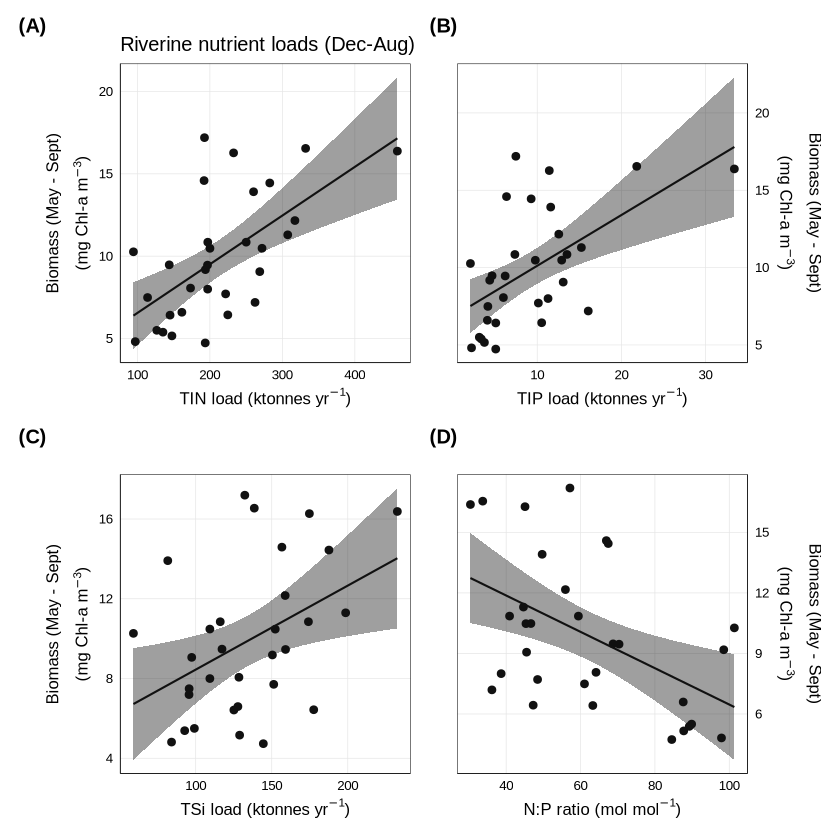

In [9]:
# ============================================================================
# ANALYSIS: Riverine nutrient loads vs summer Chl-a (correlation)
# ============================================================================

library(dplyr)
library(ggplot2)
library(lubridate)
library(patchwork)

# Step 1: Calculate annual riverine nutrient loads (Dec previous year - Aug current year)
river_analysis <- river_daily %>%
  filter(river %in% c("haringvliet", "nieuw_waterweg", "lijssele", "lijsselw")) %>%
  mutate(water_year = if_else(month %in% 12, year + 1, year)) %>%
  filter(month %in% c(12, 1:8)) %>%
  group_by(water_year) %>%
  summarise(
    TN_load_t  = sum(totalN_t_d, na.rm = TRUE),
    TP_load_t  = sum(totalP_t_d, na.rm = TRUE),
    TSi_load_t = sum(silicate_t_d, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(
    TN_load_kt  = TN_load_t / 1000,
    TP_load_kt  = TP_load_t / 1000,
    TSi_load_kt = TSi_load_t / 1000
  ) %>%
  rename(year = water_year) %>%
  filter(year >= 1989, year <= 2023) %>%
  arrange(year)

# Step 2: Calculate summer chlorophyll (May-September)
chl_summer <- Jetty_df %>%
  mutate(month = month(timestamp), year = year(timestamp)) %>%
  filter(month %in% 5:9) %>%
  group_by(year) %>%
  summarise(
    Chl_summer_mean = mean(Chl, na.rm = TRUE),
    Chl_summer_sd   = sd(Chl, na.rm = TRUE),
    n_chl = n(),
    .groups = "drop"
  ) %>%
  filter(year >= 1989, year <= 2023) %>%
  arrange(year)

# Step 3: Merge and prepare analysis dataframe
problem_years <- c(1995:1998)
analysis_df <- river_analysis %>%
  inner_join(chl_summer, by = "year") %>%
  filter(!(year %in% problem_years)) %>%
  mutate(NP_ratio = (TN_load_kt / 14) / (TP_load_kt / 31)) %>%
  arrange(year)

# Step 4: Models for correlation analysis
model_tn_chl  <- lm(Chl_summer_mean ~ TN_load_kt, data = analysis_df)
model_tp_chl  <- lm(Chl_summer_mean ~ TP_load_kt, data = analysis_df)
model_tsi_chl <- lm(Chl_summer_mean ~ TSi_load_kt, data = analysis_df)
model_np_chl  <- lm(Chl_summer_mean ~ NP_ratio, data = analysis_df)

# Step 5: Publication theme (aligned with nutrient trend/light trend cells)
nut_theme <- theme_minimal(base_size = 10) +
  theme(
    text             = element_text(family = "Arial", color = "black"),
    panel.grid.major = element_line(color = "grey90", linewidth = 0.2),
    panel.grid.minor = element_blank(),
    panel.border     = element_rect(fill = NA, color = "black", linewidth = 0.3),
    axis.title       = element_text(size = 10, face = "plain"),
    axis.text        = element_text(size = 8, color = "black"),
    axis.line        = element_line(color = "black", linewidth = 0.2),
    plot.margin      = unit(c(2, 2, 2, 2), "mm")
  )

# Helper to create consistent scatter + linear trend panel
plot_corr_panel <- function(data, x_var, x_lab, panel_title = "", show_x_title = FALSE, right_axis = FALSE) {
  p <- ggplot(data, aes(x = .data[[x_var]], y = Chl_summer_mean)) +
    geom_point(color = "#111111", size = 1.8) +
    geom_smooth(
      method = "lm", se = TRUE,
      color = "#111111", linetype = "solid", linewidth = 0.6,
      fill = adjustcolor("#111111", alpha.f = 0.18)
    ) +
    labs(
      title = panel_title,
      x = if (show_x_title) x_lab else "",
      y = expression(atop("Biomass (May - Sept)", "(mg Chl-a " * m^{-3} * ")"))
    ) +
    nut_theme

  if (right_axis) {
    p <- p +
      scale_y_continuous(position = "right") +
      theme(
        axis.title.y.left = element_blank(),
        axis.text.y.left = element_blank(),
        axis.ticks.y.left = element_blank(),
        axis.title.y.right = element_text(size = 10, face = "plain"),
        axis.text.y.right = element_text(size = 8, color = "black")
      )
  }

  p
}

# Step 6: Build 2x2 panel figure
p_tn_chl <- plot_corr_panel(
  analysis_df,
  x_var = "TN_load_kt",
  x_lab = expression("TIN load (ktonnes yr"^{-1}*")"),
  panel_title = "Riverine nutrient loads (Dec-Aug)",
  show_x_title = TRUE,
  right_axis = FALSE
)

p_tp_chl <- plot_corr_panel(
  analysis_df,
  x_var = "TP_load_kt",
  x_lab = expression("TIP load (ktonnes yr"^{-1}*")"),
  panel_title = "",
  show_x_title = TRUE,
  right_axis = TRUE
)

p_tsi_chl <- plot_corr_panel(
  analysis_df,
  x_var = "TSi_load_kt",
  x_lab = expression("TSi load (ktonnes yr"^{-1}*")"),
  panel_title = "",
  show_x_title = TRUE,
  right_axis = FALSE
)

p_np_chl <- plot_corr_panel(
  analysis_df,
  x_var = "NP_ratio",
  x_lab = expression("N:P ratio (mol mol"^{-1}*")"),
  panel_title = "",
  show_x_title = TRUE,
  right_axis = TRUE
)

p_r_nut_chl <- (p_tn_chl + p_tp_chl) / (p_tsi_chl + p_np_chl) +
  plot_annotation(tag_levels = "A", tag_prefix = "(", tag_suffix = ")") &
  theme(plot.tag = element_text(face = "bold", hjust = 0, vjust = 1))

print(p_r_nut_chl)

# Step 7: Correlation + trend statistics summary table
extract_corr_stats <- function(data, x_var, x_label, x_unit) {
  fml <- as.formula(paste("Chl_summer_mean ~", x_var))
  model <- lm(fml, data = data)
  s <- summary(model)
  coef_tab <- s$coefficients
  cor_obj <- cor.test(data[[x_var]], data$Chl_summer_mean, method = "pearson")

  data.frame(
    Predictor = x_label,
    Slope = unname(coef_tab[x_var, "Estimate"]),
    P_value = unname(coef_tab[x_var, "Pr(>|t|)"]),
    R_squared = unname(s$r.squared),
    Pearson_r = unname(cor_obj$estimate),
    Pearson_p = unname(cor_obj$p.value),
    N = nrow(data),
    Unit = paste0("(ug L^-1) per ", x_unit),
    row.names = NULL
  )
}

nutrient_chla_correlation_stats <- bind_rows(
  extract_corr_stats(analysis_df, "TN_load_kt", "TIN load", "ktonnes yr^-1"),
  extract_corr_stats(analysis_df, "TP_load_kt", "TIP load", "ktonnes yr^-1"),
  extract_corr_stats(analysis_df, "TSi_load_kt", "TSi load", "ktonnes yr^-1"),
  extract_corr_stats(analysis_df, "NP_ratio", "N:P ratio", "mol mol^-1")
)

print(nutrient_chla_correlation_stats)

# Step 8: Save publication-ready PDF

ggsave(
  filename = file.path(graph_dir, "Nutrient_vs_SummerChla_correlation.pdf"),
  plot = p_r_nut_chl,
  device = grDevices::cairo_pdf,
  width = 180,
  height = 150,
  units = "mm",
  bg = "white"
)

# Figure SI 4. PI photosynthetic performance

Warning message in sqrt(PI_output$a_fit * PI_output$c_fit):
“NaNs produced”


[1]   1.192168 582.247541

[1]   28.97147 1171.00019

Warning message:
“Removed 65 rows containing missing values or values outside the scale range
(`geom_point()`).”


[1]   1.192168 582.247541

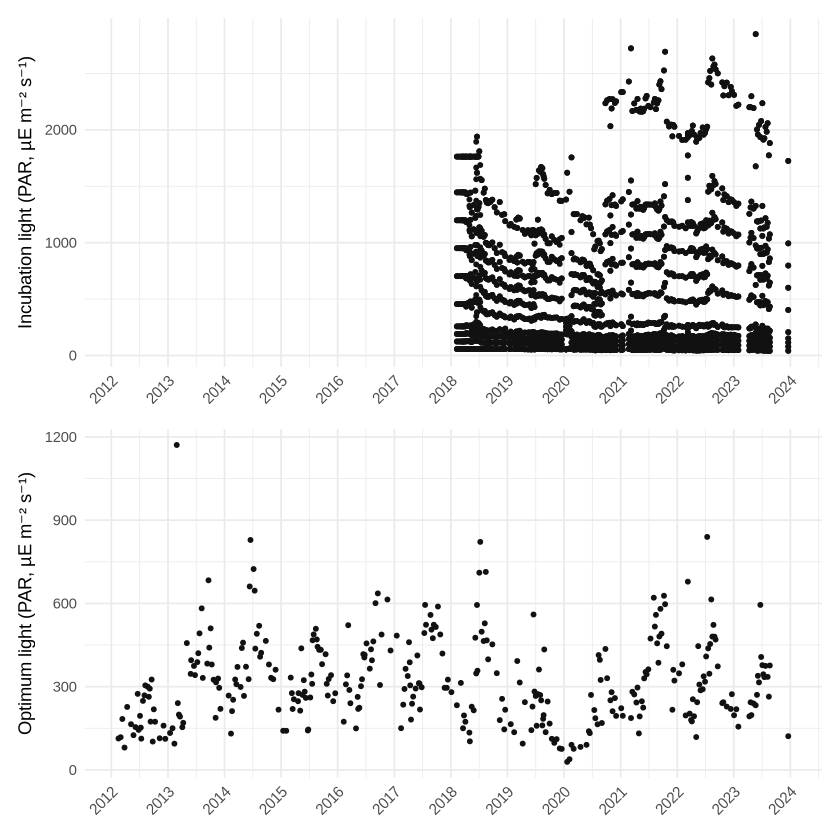

In [36]:
require(lubridate)
require(ggplot2)
require(patchwork)

PI_input <- read.csv(file = paste(wd_path,"/processed_data/","PI_Input.csv",sep=""), header = TRUE)
#head(PI_input)

PI_output <- read.csv(file = paste(PI_output_dir,"output_v2.csv",sep=""), header = TRUE)
#head(PI_output)

PI_output$P_max = 1/(PI_output$b_fit + 2*sqrt(PI_output$a_fit*PI_output$c_fit))
PI_output$E_opt = PI_output$P_max*PI_output$c_fit
#head(PI_output)
range(PI_output$P_max, na.rm=TRUE)
range(PI_output$E_opt, na.rm=TRUE)

PI_output$datum <- ymd_hms(PI_output$datum)

# make sure data are ordered by time for plotting
PI_output <- PI_output %>% arrange(datum)

# basic ggplot style graphs to match later figures
p_opt <- ggplot(PI_output, aes(x = datum, y = E_opt)) +
  geom_point(fill = "#111111", color = "#111111", size = 1) +
  labs(y = "Optimum light (PAR, µE m⁻² s⁻¹)") +
  scale_x_datetime(date_breaks = "1 year", date_labels = "%Y") +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    axis.title.x = element_blank()
  )

PI_input <- PI_input %>% left_join(
    PI_output %>% select(HWcode, datum),
    by = c("HW" = "HWcode")
)

# ensure PI_input has datum as datetime
PI_input$datum <- ymd_hms(PI_input$datum)
PI_input <- PI_input %>% arrange(datum)

# set values before February 2018 to NA so the period appears empty
PI_input_post2018 <- PI_input %>%
  mutate(Incubation_light = if_else(datum < ymd_hms("2018-02-01 00:00:00"), NA_real_, Incubation_light))

p_light <- ggplot(PI_input_post2018, aes(x = datum, y = Incubation_light)) +
  geom_point(fill = "#111111", color = "#111111", size = 1, na.rm = TRUE) +
  labs(y = "Incubation light (PAR, µE m⁻² s⁻¹)") +
  scale_x_datetime(date_breaks = "1 year", date_labels = "%Y") +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    axis.title.x = element_blank()
  )

# display side by side
p_light <- p_light + p_opt + plot_layout(ncol = 1)
p_light

range(PI_output$P_max, na.rm=TRUE)
#ggsave(
#   filename = file.path(graph_dir, "incubation_light.png"),
#   plot = p_light,
#   device = "png",
#   width = 8,       # Standard single-column width (inches)
#   height = 8,        # Adjusted height for better proportions
#   units = "in",
#   dpi = 600,         # Publication quality
#   bg = "white"
#)


# Light vs Nutrient limitation
Cloern approach for 2012-2023
- calculation of paritial derivative for each limiting factors

In [9]:
require(dplyr)
require(ggplot2)
library(lubridate)
library(ggplot2)
library(zoo)

# load Eilers-Peeters a, b, c parameters
PI_curve <- read.csv(paste(PI_output_dir,"output_v2.csv",sep=""))
PI_curve <- PI_curve[,c("datum", "HWcode", "a_fit", "b_fit", "c_fit")]
PI_curve$P_max = 1/(2*sqrt(PI_curve$a_fit*PI_curve$c_fit)+PI_curve$b_fit) # maximum productivity in mg C/h
PI_curve$I_opt = sqrt(PI_curve$c_fit/PI_curve$a_fit) # optimum light intensity in uE/m2/s
PI_curve$initial_slop = 1/PI_curve$c_fit

PI_curve$datum <- PI_curve$datum%>%ymd_hms
names(PI_curve)[3:5] = c("PI_a", "PI_b", "PI_c")

#plot(PI_curve$datum, PI_curve$P_max, ylim=c(0,40), pch=19, ylab="Max productivity (mg C/h)")
#plot(PI_curve$datum, PI_curve$I_opt, ylim=quantile(PI_curve$I_opt%>%na.omit, c(0,0.99)), pch=19, ylab="optimum light in uE/m2/s")
#plot(PI_curve$datum, PI_curve$initial_slop, ylim=quantile(PI_curve$initial_slop%>%na.omit, c(0,0.99)), pch=19, ylab="initial slope in mgC/h (uE/m2/s)-1")

Jetty_df = read.csv(file=paste(wd_path,"/processed_data/","Jetty_HWseries.csv",sep=""), fileEncoding = "UTF-8", na.strings=c("", "NA"), header=TRUE)
Jetty_df$timestamp <- Jetty_df$timestamp%>%ymd_hms()


#plot(Jetty_df$timestamp,Jetty_df$PO4, ylab=c("PO4 (ug/L)"), t="b")
#plot(Jetty_df$timestamp,Jetty_df$NO2+Jetty_df$NO3+Jetty_df$NH4, ylab=c("DIN (ug/L)"), t="b")
#plot(Jetty_df$timestamp,Jetty_df$Si, ylab=c("DIN (ug/L)"), t="b")

PI_Jetty <- merge(PI_curve, Jetty_df, by.x="HWcode", by.y="SampleID")
PI_Jetty$DIN <- PI_Jetty$NH4 + PI_Jetty$NO3 + PI_Jetty$NO2

# Load necessary libraries
# Add a new column for the day of the year
PI_Jetty$day_of_year <- yday(PI_Jetty$datum)

PI_Jetty <- PI_Jetty %>%
  mutate(date = as.Date(datum),
         year = year(datum),
         month = month(datum)
  )

#######
# KNMI measurements
#######

hr_KNMI_filepath_2011_2020 <- paste(wd_path,"/rawdata/","uurgeg_235_2011-2020.txt",sep="")
hr_KNMI_filepath_2021_2030 <- paste(wd_path,"/rawdata/","uurgeg_235_2021-2030.txt",sep="")

hr_KNMI_deKooy_2011_20 <- read.table(hr_KNMI_filepath_2011_2020,header=TRUE, sep=",")
hr_KNMI_deKooy_2021_30 <- read.table(hr_KNMI_filepath_2021_2030, header=TRUE, sep=",")

hr_KNMI_deKooy <- rbind(hr_KNMI_deKooy_2011_20, hr_KNMI_deKooy_2021_30)

# hr_KNMI_deKooy$PAR = hr_KNMI_deKooy$Q*1e4/3600*2.515 # Conversion from KNMI 1J/(W m-2) to PAR (uE m-2 s-1), reference Brinkman et al., 2015, EMS-Dollard data report
hr_KNMI_deKooy$Datum <- paste(hr_KNMI_deKooy$YYYYMMDD, hr_KNMI_deKooy$HH,sep=" ")%>%ymd_h
hr_KNMI_deKooy <- hr_KNMI_deKooy[which(year(hr_KNMI_deKooy$Datum)%in%2012:2023),]

PAR_frac = 0.45  # PAR is 45% of global radiation
Reflec_frac = 0.07 # reflecting of solar radiation at the surface by 5-10%, ref Brinkman et al., 2015
hr_KNMI_deKooy$PAR = hr_KNMI_deKooy$Q*PAR_frac*(1-Reflec_frac) # in (J/cm2/h) over an hour at water surface

# convert to photon flux (uE m-2 s-1); reference Brinkman et al., 2015,    EMS-Dollard data report
sec_per_hr = 3600 # seconds in an hour
cm2_to_m2 = 1e4 
conversion_factor = 4.66 # (μE/m2/s)/(W/m2); reference Jacobs et al., 2021, https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0246012 (in Brinkman et al., 2015 data report this conversion factor is 2.515)

day_ave_PAR <- aggregate(hr_KNMI_deKooy$PAR, by = list(as.Date(hr_KNMI_deKooy$Datum)),FUN=mean) # in (J/cm2/h)
names(day_ave_PAR) <- c("date","PAR")
day_ave_PAR$I_surf <- day_ave_PAR$PAR/3600*3600*24*cm2_to_m2*conversion_factor*1e-6 # in (mol E/m2/day)

# plot(day_ave_PAR$date, day_ave_PAR$I_surf, ylab="(mol E/m2/day)")

# Add a month column
day_ave_PAR <- day_ave_PAR[,c("date","I_surf")]
names(day_ave_PAR) <- c("date","irradiance")
day_ave_PAR <- day_ave_PAR %>%
  mutate(year = year(date),
         month = month(date)
  )


Nut_Light_limitation_df = merge(PI_Jetty,day_ave_PAR[,c("date","irradiance")], by.x = c("date"), by.y=c("date"))
Nut_Light_limitation_df = Nut_Light_limitation_df[,-which(names(Nut_Light_limitation_df)=="timestamp")]

# Define the integrate_primary_production function
integrate_primary_production <- function(z, PAR_daily, k, a, b, c) {
  light_hourly <- PAR_daily * 1e6 / (24 * 3600) # Convert from mol E/m2/day to umol E/m2/s
  light_at_depth <- light_hourly * exp(-k * z)
  production <- (light_at_depth / (a * light_at_depth^2 + b * light_at_depth + c)) * 24 # PP in mg C/m2/day
  return(production)
}

# Calcualate the average light over depth:
I_ave_depth <- function(PAR_daily, k, z) {
  I_mean_day_over_depth <- (PAR_daily / (k * z)) * (1 - exp(-(k * z)))
}

# Define the growth rate function

growth_rate <- function(PAR_daily, nutrient, Temp, k, a, b, c, Kn, z, Chl) {
  I_mean_day_over_depth <- (PAR_daily / (k * z)) * (1 - exp(-(k * z)))
  Chla_C <- 0.003 + 0.0154 * exp(0.050 * Temp) * exp(-0.059 * I_mean_day_over_depth) * (nutrient / (nutrient + Kn))
  
  # Depth-integrated primary production
  PP_over_depth <- integrate(integrate_primary_production, lower = 0, upper = z,
                             PAR_daily = PAR_daily, k = k, a = a, b = b, c = c)$value / z
  
  mu <- 0.85 * PP_over_depth/Chl * Chla_C - 0.015
  return(mu)
}

# Five-point formula for partial derivative with respect to light
partial_derivative_light <- function(light, nutrient, h, Temp, k, a, b, c, Kn, z, Chl) {
  (growth_rate(light * (1 - 2 * h), nutrient, Temp, k, a, b, c, Kn, z, Chl) -
     8 * growth_rate(light * (1 - h), nutrient, Temp, k, a, b, c, Kn, z, Chl) +
     8 * growth_rate(light * (1 + h), nutrient, Temp, k, a, b, c, Kn, z, Chl) -
     growth_rate(light * (1 + 2 * h), nutrient, Temp, k, a, b, c, Kn, z, Chl)) / (12 * h * light)
}

# Five-point formula for partial derivative with respect to nutrient
partial_derivative_nutrient <- function(light, nutrient, h, Temp, k, a, b, c, Kn, z, Chl) {
  (growth_rate(light, nutrient * (1 - 2 * h), Temp, k, a, b, c, Kn, z, Chl) -
     8 * growth_rate(light, nutrient * (1 - h), Temp, k, a, b, c, Kn, z, Chl) +
     8 * growth_rate(light, nutrient * (1 + h), Temp, k, a, b, c, Kn, z, Chl) -
     growth_rate(light, nutrient * (1 + 2 * h), Temp, k, a, b, c, Kn, z, Chl)) / (12 * h * nutrient)
}


Nut_Light_limitation_df <- Nut_Light_limitation_df %>%
  arrange(date) %>%
  mutate(
    across(
      .cols = -(1:3),  # all columns except the first two
      .fns  = ~ na.approx(., x = date, na.rm = FALSE)
    )
  )

# Nut_Light_limitation_df = na.omit(Nut_Light_limitation_df[,PP_input_vars])
names(Nut_Light_limitation_df)[which(names(Nut_Light_limitation_df)=="T")] <- "T_insitu" 
# Main loop for calculations

for (i in 1:nrow(Nut_Light_limitation_df)) {
  Date <- Nut_Light_limitation_df$date[i]
  Nuts <- c(DIN = Nut_Light_limitation_df$DIN[i], DSi = Nut_Light_limitation_df$Si[i], DP = Nut_Light_limitation_df$PO4[i])
  # Knuts <- c(K_N = 1.5, K_Si = 1.5, K_P = 0.15) # Cloern 1999 for K_N, and philippart et al., (2007) for the ratio between K_N/K_Si=1, K_N/K_P=10
  Knuts <- c(K_N = 2, K_Si = 2, K_P = 0.2) # Philippart et al., (2007)
  # Knuts <- c(K_N = 1.5, K_Si = 5, K_P = 0.5) # Loebl et al., (2009); attention they altered the procedure of Cloern and took the monthly mean irradiance, instead of the average value from the 3 days around the middle of each month to reduce short-term variability.
  
  Nut.Lim.ind <- which.min(c(Nuts["DIN"] / (Nuts["DIN"] + Knuts["K_N"]),
                             Nuts["DSi"] / (Nuts["DSi"] + Knuts["K_Si"]),
                             Nuts["DP"] / (Nuts["DP"] + Knuts["K_P"])))
  Nut_Light_limitation_df$Lim_Nut[i] <- names(Nuts)[Nut.Lim.ind]
  Nut <- Nuts[Nut.Lim.ind];names(Nut)<-NULL
  Kn <- Knuts[Nut.Lim.ind];names(Kn)<-NULL
  
  parameters <- c(Temp = Nut_Light_limitation_df$T_insitu[i],
                  k = Nut_Light_limitation_df$Kd_Secci[i],
                  a = Nut_Light_limitation_df$PI_a[i],
                  b = Nut_Light_limitation_df$PI_b[i],
                  c = Nut_Light_limitation_df$PI_c[i],
                  PAR_daily = Nut_Light_limitation_df$irradiance[i],
                  Chl = Nut_Light_limitation_df$Chl[i],
                  Nut = Nut,
                  Kn = Kn,
                  K_I = 2.4, # mol E/m2/d, based on Cloern 1999
                  z = 4.6)
  
  # Nut_Light_limitation_df$mu[i] <- with(as.list(parameters), {
  #   return(growth_rate(PAR_daily = PAR_daily, nutrient = Nut, Temp = Temp, k = k, a = a, b = b, c = c, Kn = Kn, z = z))
  # })
  Nut_Light_limitation_df$mu[i] =
    growth_rate(PAR_daily = parameters["PAR_daily"], nutrient = parameters["Nut"], Temp = parameters["Temp"], k = parameters["k"], a = parameters["a"], b = parameters["b"], c = parameters["c"], Kn = parameters["Kn"], z = parameters["z"], Chl = parameters["Chl"])
  
  Nut_Light_limitation_df$I_depth[i] = I_ave_depth(PAR_daily = parameters["PAR_daily"], k = parameters["k"], z = parameters["z"])
  Nut_Light_limitation_df$nutrient_limitation[i] = min(c(Nuts["DIN"] / (Nuts["DIN"] + Knuts["K_N"]),
                                                               Nuts["DSi"] / (Nuts["DSi"] + Knuts["K_Si"]),
                                                               Nuts["DP"] / (Nuts["DP"] + Knuts["K_P"])))
  
  
  light_nonDIM <- parameters["PAR_daily"] / parameters["K_I"]
  Nut_nonDIM <- parameters["Nut"] / parameters["Kn"]
  
  Nut_Light_limitation_df$partial_dev_light[i] <- partial_derivative_light(
    light = light_nonDIM, nutrient = Nut_nonDIM, h = 0.0025,
    Temp = parameters["Temp"], k = parameters["k"], a = parameters["a"],
    b = parameters["b"], c = parameters["c"], Kn = parameters["Kn"], z = parameters["z"], Chl = parameters["Chl"]
  )
  
  Nut_Light_limitation_df$partial_dev_nutrient[i] <- partial_derivative_nutrient(
    light = light_nonDIM, nutrient = Nut_nonDIM, h = 0.0025,
    Temp = parameters["Temp"], k = parameters["k"], a = parameters["a"],
    b = parameters["b"], c = parameters["c"], Kn = parameters["Kn"], z = parameters["z"], Chl = parameters["Chl"]
  )
  
  Nut_Light_limitation_df$ln_R_light_to_nutrient[i] <- log(Nut_Light_limitation_df$partial_dev_light[i] / Nut_Light_limitation_df$partial_dev_nutrient[i])
}

Nut_Light_limitation_df$Lim_Nut <- factor(Nut_Light_limitation_df$Lim_Nut, levels=c("DIN","DSi","DP"))

Nut_Light_limitation_df$day_of_year = yday(Nut_Light_limitation_df$date)
Nut_Light_limitation_df$year <- as.factor(year(Nut_Light_limitation_df$date))
Nut_Light_limitation_df$Lim_Nut <- factor(Nut_Light_limitation_df$Lim_Nut, levels=c("DIN","DP","DSi"))
Nut_Light_limitation_df <- Nut_Light_limitation_df%>%
  mutate(limiting_factor= case_when(
    ln_R_light_to_nutrient > 0 ~ "light",
    TRUE ~ Lim_Nut
  ))
Nut_Light_limitation_df <- Nut_Light_limitation_df%>%
  mutate(
    line_thickness = case_when(
      limiting_factor == "light" ~ ln_R_light_to_nutrient,
      limiting_factor %in% c("DIN", "DP", "DSi") ~ abs(ln_R_light_to_nutrient)
    ))

# write.csv(Nut_Light_limitation_df, file = paste(PP_cal_dir,"Nut_Light_limitation_Jetty40.csv",sep=""),row.names = F)




Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


Warning message in sqrt(PI_curve$a_fit * PI_curve$c_fit):
“NaNs produced”
Warning message in sqrt(PI_curve$c_fit/PI_curve$a_fit):
“NaNs produced”


# Figure 9A. Seasonality for Chla & PP & mu


Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine


Warning message in sqrt(PI_curve$a_fit * PI_curve$c_fit):
“NaNs produced”
Warning message in sqrt(PI_curve$c_fit/PI_curve$a_fit):
“NaNs produced”



Family: Gamma 
Link function: log 

Formula:
daily_PP ~ s(doy, bs = "tp")

Parametric coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   5.7233     0.0135   423.9   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Approximate significance of smooth terms:
         edf Ref.df    F p-value    
s(doy) 8.944  8.999 1179  <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

R-sq.(adj) =  0.405   Deviance explained = 67.6%
GCV = 0.62698  Scale est. = 0.79895   n = 4382

[1] 58511.74


Family: Gamma 
Link function: log 

Formula:
Chl ~ s(doy, bs = "tp")

Parametric coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  1.94396    0.03218   60.41   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Approximate significance of smooth terms:
         edf Ref.df     F p-value    
s(doy) 8.643  8.963 35.18  <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

R-sq.(adj) =   0.22   Deviance explained = 46.1%
GCV = 0.36535  Scale est. = 0.48769   n = 471

[1] 2591.355

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_line()`).”


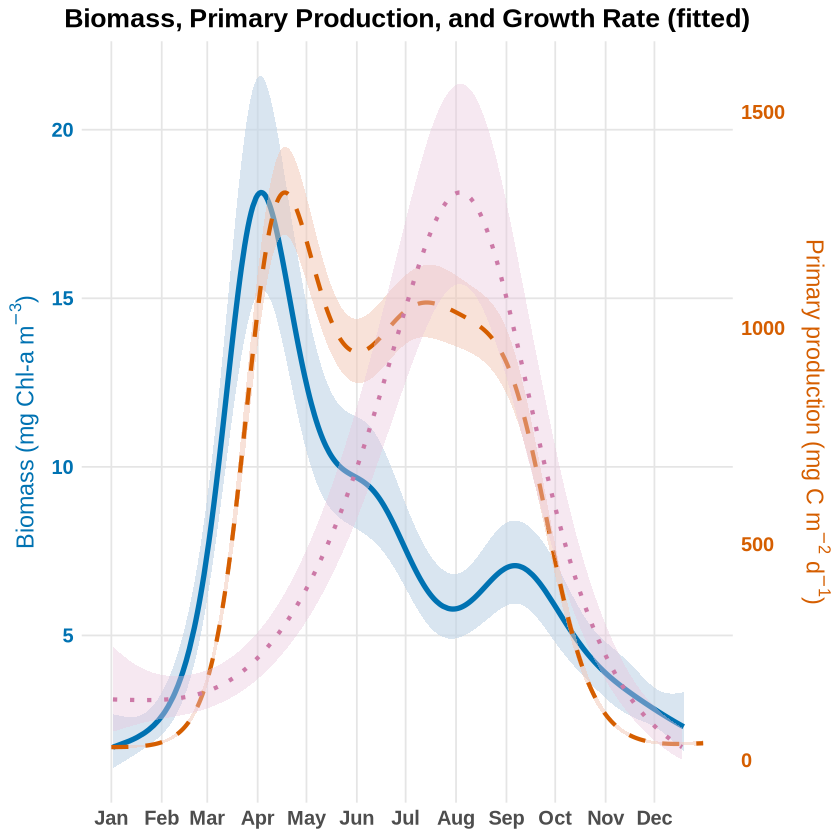

In [15]:
require(dplyr)
require(ggplot2)
library(patchwork)
library(mgcv)
library(ggplot2)
library(lubridate)
library(gridExtra)
library(plotly)
library(pracma)

Nut_Light_limitation_df <- read.csv(paste(PP_cal_dir,"Nut_Light_limitation_Jetty40.csv",sep=""))
Nut_Light_limitation_df$Lim_Nut <- factor(Nut_Light_limitation_df$Lim_Nut, levels=c("DIN","DP","DSi"))
Nut_Light_limitation_df <- Nut_Light_limitation_df %>% filter(mu>=0)

gam_model_mu <- gam(mu ~ s(day_of_year, bs = "tp"), 
                 family = Gamma(link = "log"), 
                 data = Nut_Light_limitation_df)

gam_pred_mu <- predict(gam_model_mu, 
                    newdata = Nut_Light_limitation_df,
                    type="link",se.fit = TRUE)

# Predict values using the fitted model
Nut_Light_limitation_df <- Nut_Light_limitation_df%>%
  mutate(
    mu_Fitted = exp(gam_pred_mu$fit),
    mu_lower_ci = exp(gam_pred_mu$fit - 1.96*gam_pred_mu$se.fit),
    mu_upper_ci = exp(gam_pred_mu$fit + 1.96*gam_pred_mu$se.fit)
  )

# load Eilers-Peeters a, b, c parameters
PI_curve <- read.csv(paste(PI_output_dir,"output_v2.csv",sep=""))
PI_curve <- PI_curve[,c("datum", "HWcode", "a_fit", "b_fit", "c_fit")]
PI_curve$P_max = 1/(2*sqrt(PI_curve$a_fit*PI_curve$c_fit)+PI_curve$b_fit) # maximum productivity in mg C/mg chla/h
PI_curve$I_opt = sqrt(PI_curve$c_fit/PI_curve$a_fit) # optimum light intensity in uE/m2/s
PI_curve$initial_slop = 1/PI_curve$c_fit

PI_curve$datum <- PI_curve$datum%>%ymd_hms


# Plotting PP against day of years
sumDay_PP_total <- read.csv(file = paste(wd_path,"/PP_cal/","sumDay_PP.csv",sep=""))
sumDay_PP_total$date <- dmy(sumDay_PP_total$date)
sumDay_PP_total$doy <- yday(sumDay_PP_total$date)

sumDay_PP_total$daily_PP[sumDay_PP_total$daily_PP <= 0] <- 0.001

Jetty_df = read.csv(file=paste(wd_path,"/processed_data/","Jetty_HWseries.csv",sep=""), fileEncoding = "UTF-8", na.strings=c("", "NA"), header=TRUE)
Jetty_df$timestamp <- Jetty_df$timestamp%>%ymd_hms()
Jetty_df$doy <- yday(Jetty_df$timestamp)
Jetty_df$Day <- yday(Jetty_df$timestamp)
Jetty_df$Year <- year(Jetty_df$timestamp)
Jetty_df$DIN <- Jetty_df$NH4 + Jetty_df$NO2 + Jetty_df$NO3

gam_model <- gam(daily_PP ~ s(doy, bs = "tp"), 
                 family = Gamma(link = "log"), 
                 data = sumDay_PP_total)

gam_pred <- predict(gam_model, 
                    newdata = sumDay_PP_total,
                    type="link",se.fit = TRUE)

# Predict values using the fitted model
sumDay_PP_total <- sumDay_PP_total%>%
  mutate(
    Fitted = exp(gam_pred$fit),
    lower_ci = exp(gam_pred$fit - 1.96*gam_pred$se.fit),
    upper_ci = exp(gam_pred$fit + 1.96*gam_pred$se.fit)
  )

Jetty_df_2012_2023 <- Jetty_df[which(Jetty_df$Year>=2012&Jetty_df$Year<=2023),]
Chl_gam_model <- gam(Chl ~ s(doy, bs = "tp"), 
                     family = Gamma(link = "log"), 
                     data = Jetty_df_2012_2023)

Chl_gam_pred <- predict(Chl_gam_model, 
                        newdata = Jetty_df_2012_2023,
                        type="link",se.fit = TRUE)

# Predict values using the fitted model
sumDay_PP_total <- sumDay_PP_total%>%
  mutate(
    Fitted = exp(gam_pred$fit),
    lower_ci = exp(gam_pred$fit - 1.96*gam_pred$se.fit),
    upper_ci = exp(gam_pred$fit + 1.96*gam_pred$se.fit)
  )

Jetty_df_2012_2023 <- Jetty_df_2012_2023%>%
  mutate(
    Fitted = exp(Chl_gam_pred$fit),
    lower_ci = exp(Chl_gam_pred$fit - 1.96*Chl_gam_pred$se.fit),
    upper_ci = exp(Chl_gam_pred$fit + 1.96*Chl_gam_pred$se.fit)
  )

summary(gam_model) # 0.405   
AIC(gam_model)

summary(Chl_gam_model)
AIC(Chl_gam_model)


# --- Plot: Biomass (Chl-a) on left, PP and fitted mu on right ---
# Color-blind safe palette
chla_color <- "#0072B2"   # Blue for Chla
pp_color <- "#D55E00"     # Orange for PP
# mu_color <- "#E63946"     # Red for growth rate
mu_color <- "#CC79A7"     # Red for growth rate
chla_ribbon <- "#BFD3E6"  # Soft blue tint
pp_ribbon <- "#F2C6B4"    # Soft orange tint
# mu_ribbon <- "#F7B7A3"    # Soft red tint
mu_ribbon <- "#E9C6DC"    # Soft red tint


# Ranges for scaling
range_chla <- range(Jetty_df_2012_2023$Fitted, na.rm = TRUE)
range_PP <- range(sumDay_PP_total$Fitted, na.rm = TRUE)
range_mu <- range(Nut_Light_limitation_df$mu_Fitted, na.rm = TRUE)

# Scale functions: scale PP and mu to Chl-a axis
scale_PP_to_chla <- function(x) {
  (x - min(range_PP)) / diff(range_PP) * diff(range_chla) + min(range_chla)
}
scale_mu_to_chla <- function(x) {
  (x - min(range_mu)) / diff(range_mu) * diff(range_chla) + min(range_chla)
}
# Inverse for secondary axis
scale_chla_to_PP <- function(x) {
  (x - min(range_chla)) / diff(range_chla) * diff(range_PP) + min(range_PP)
}
scale_chla_to_mu <- function(x) {
  (x - min(range_chla)) / diff(range_chla) * diff(range_mu) + min(range_mu)
}

# Month breaks for x-axis
month_breaks <- yday(as.Date(paste0("2001-", sprintf("%02d", 1:12), "-01")))
month_labels <- month.abb

# Plot
biomass_plot <- ggplot(Jetty_df_2012_2023, aes(x = doy)) +
  xlim(1, 365) +
  # Chl-a ribbon and line (left axis)
  geom_ribbon(aes(ymin = lower_ci, ymax = upper_ci), fill = chla_ribbon, alpha = 0.6) +
  geom_line(aes(y = Fitted), color = chla_color, size = 1.5) +
  # PP ribbon and line (scaled to Chl-a, right axis)
  geom_ribbon(data = sumDay_PP_total, aes(x = doy, ymin = scale_PP_to_chla(lower_ci), ymax = scale_PP_to_chla(upper_ci)), 
  fill = pp_ribbon, alpha = 0.5, inherit.aes = FALSE) +
  geom_line(data = sumDay_PP_total, aes(x = doy, y = scale_PP_to_chla(Fitted)), 
  color = pp_color, size = 1.2, inherit.aes = FALSE, linetype = "dashed") +
  # mu ribbon and line (scaled to Chl-a, right axis, using fitted values)
  geom_ribbon(data = Nut_Light_limitation_df, aes(x = day_of_year, ymin = scale_mu_to_chla(mu_lower_ci), ymax = scale_mu_to_chla(mu_upper_ci)), fill = mu_ribbon, alpha = 0.4, inherit.aes = FALSE) +
  geom_line(data = Nut_Light_limitation_df, aes(x = day_of_year, y = scale_mu_to_chla(mu_Fitted)), 
  color = mu_color, size = 1.2, inherit.aes = FALSE, linetype = "dotted") +
  # Y-axes
  scale_y_continuous(
    name = expression("Biomass (mg Chl-a m"^{-3}*")"),
    sec.axis = sec_axis(~scale_chla_to_PP(.), name = expression("Primary production (" * mg~C~m^{-2}~d^{-1} * ")"))
  ) +
  # Add a third axis for mu using annotation (not a true axis, but legend/label)
  # X-axis with month labels
  scale_x_continuous(
    breaks = month_breaks,
    labels = month_labels,
    limits = c(1,365)
  ) +
  labs(
    title = "Biomass, Primary Production, and Growth Rate (fitted)",
    color = "Variable"
  ) +
  theme_minimal() +
  theme(
    axis.title.x = element_blank(),
    axis.title.y.left = element_text(size = 14, face = "bold", color = chla_color),
    axis.title.y.right = element_text(size = 14, face = "bold", color = pp_color),
    axis.text.y.left = element_text(size = 12, face = "bold", color = chla_color),
    axis.text.y.right = element_text(size = 12, face = "bold", color = pp_color),
    axis.text.x = element_text(size = 12, face = "bold"),
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
    panel.grid.major = element_line(color = "gray90"),
    panel.grid.minor = element_blank(),
    legend.position = "top"
  ) 
biomass_plot

# Save the plot as a TIFF file
#tiff(filename = paste0(graph_dir, "PP_Chla_mu_season.tiff"), 
#     width = 3000, height = 2000, res = 300)  # 300 dpi, suitable for publication
#print(biomass_plot)
#dev.off()

# Figure 9B. Limitation seasonality

Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's linetype values.”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's linetype values.”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_line()`).”


agg_record_1459583844 
                    2

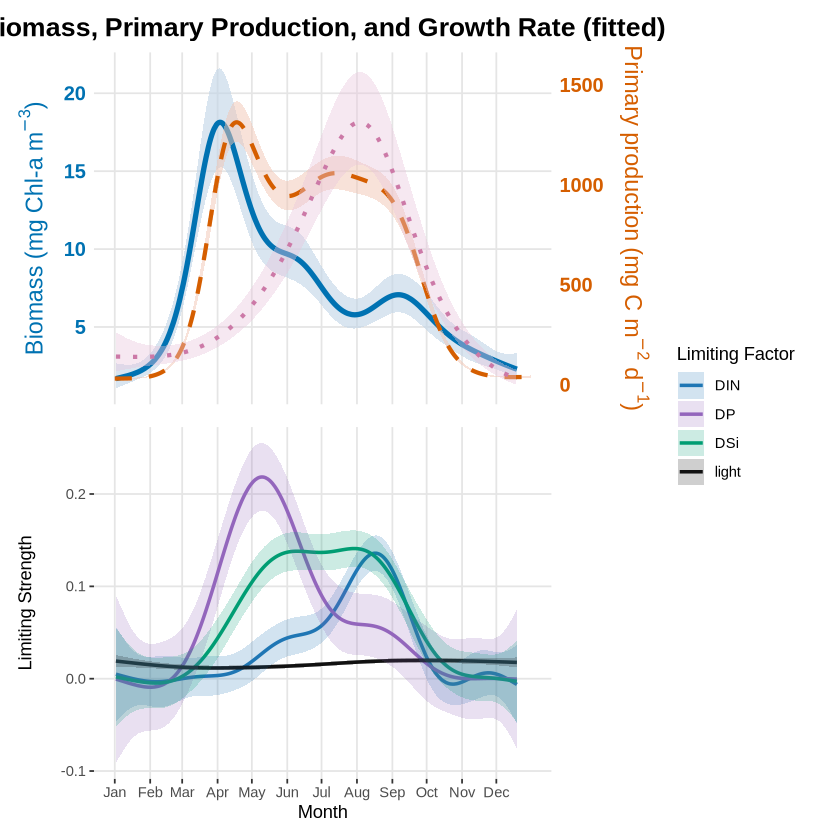

In [19]:
# Load necessary libraries
# Add a new column for the day of the year
PI_Jetty$day_of_year <- yday(PI_Jetty$datum)

PI_Jetty <- PI_Jetty %>%
  mutate(date = as.Date(datum),
         year = year(datum),
         month = month(datum)
  )

#######
# KNMI measurements
#######

hr_KNMI_filepath_2011_2020 <- paste(wd_path,"/rawdata/","uurgeg_235_2011-2020.txt",sep="")
hr_KNMI_filepath_2021_2030 <- paste(wd_path,"/rawdata/","uurgeg_235_2021-2030.txt",sep="")

hr_KNMI_deKooy_2011_20 <- read.table(hr_KNMI_filepath_2011_2020,header=TRUE, sep=",")
hr_KNMI_deKooy_2021_30 <- read.table(hr_KNMI_filepath_2021_2030, header=TRUE, sep=",")

hr_KNMI_deKooy <- rbind(hr_KNMI_deKooy_2011_20, hr_KNMI_deKooy_2021_30)

# hr_KNMI_deKooy$PAR = hr_KNMI_deKooy$Q*1e4/3600*2.515 # Conversion from KNMI 1J/(W m-2) to PAR (uE m-2 s-1), reference Brinkman et al., 2015, EMS-Dollard data report
hr_KNMI_deKooy$Datum <- paste(hr_KNMI_deKooy$YYYYMMDD, hr_KNMI_deKooy$HH,sep=" ")%>%ymd_h
hr_KNMI_deKooy <- hr_KNMI_deKooy[which(year(hr_KNMI_deKooy$Datum)%in%2012:2023),]

PAR_frac = 0.45  # PAR is 45% of global radiation
Reflec_frac = 0.07 # reflecting of solar radiation at the surface by 5-10%, ref Brinkman et al., 2015
hr_KNMI_deKooy$PAR = hr_KNMI_deKooy$Q*PAR_frac*(1-Reflec_frac) # in (J/cm2/h) over an hour at water surface

# convert to photon flux (uE m-2 s-1); reference Brinkman et al., 2015,    EMS-Dollard data report
sec_per_hr = 3600 # seconds in an hour
cm2_to_m2 = 1e4 
conversion_factor = 4.66 # (μE/m2/s)/(W/m2); reference Jacobs et al., 2021, https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0246012 (in Brinkman et al., 2015 data report this conversion factor is 2.515)

day_ave_PAR <- aggregate(hr_KNMI_deKooy$PAR, by = list(as.Date(hr_KNMI_deKooy$Datum)),FUN=mean) # in (J/cm2/h)
names(day_ave_PAR) <- c("date","PAR")
day_ave_PAR$I_surf <- day_ave_PAR$PAR/3600*3600*24*cm2_to_m2*conversion_factor*1e-6 # in (mol E/m2/day)

#plot(day_ave_PAR$date, day_ave_PAR$I_surf, ylab="(mol E/m2/day)")

# Add a month column
day_ave_PAR <- day_ave_PAR[,c("date","I_surf")]
names(day_ave_PAR) <- c("date","irradiance")
day_ave_PAR <- day_ave_PAR %>%
  mutate(year = year(date),
         month = month(date)
  )


Nut_Light_limitation_df = merge(PI_Jetty,day_ave_PAR[,c("date","irradiance")], by.x = c("date"), by.y=c("date"))
Nut_Light_limitation_df = Nut_Light_limitation_df[,-which(names(Nut_Light_limitation_df)=="timestamp")]

# Define the integrate_primary_production function
integrate_primary_production <- function(z, PAR_daily, k, a, b, c) {
  light_hourly <- PAR_daily * 1e6 / (24 * 3600) # Convert from mol E/m2/day to umol E/m2/s
  light_at_depth <- light_hourly * exp(-k * z)
  production <- (light_at_depth / (a * light_at_depth^2 + b * light_at_depth + c)) * 24 # PP in mg C/m2/day
  return(production)
}

# Calcualate the average light over depth:
I_ave_depth <- function(PAR_daily, k, z) {
  I_mean_day_over_depth <- (PAR_daily / (k * z)) * (1 - exp(-(k * z)))
}

# Define the growth rate function

growth_rate <- function(PAR_daily, nutrient, Temp, k, a, b, c, Kn, z, Chl) {
  I_mean_day_over_depth <- (PAR_daily / (k * z)) * (1 - exp(-(k * z)))
  Chla_C <- 0.003 + 0.0154 * exp(0.050 * Temp) * exp(-0.059 * I_mean_day_over_depth) * (nutrient / (nutrient + Kn))
  
  # Depth-integrated primary production
  PP_over_depth <- integrate(integrate_primary_production, lower = 0, upper = z,
                             PAR_daily = PAR_daily, k = k, a = a, b = b, c = c)$value / z
  
  mu <- 0.85 * PP_over_depth/Chl * Chla_C - 0.015
  return(mu)
}

# Five-point formula for partial derivative with respect to light
partial_derivative_light <- function(light, nutrient, h, Temp, k, a, b, c, Kn, z, Chl) {
  (growth_rate(light * (1 - 2 * h), nutrient, Temp, k, a, b, c, Kn, z, Chl) -
     8 * growth_rate(light * (1 - h), nutrient, Temp, k, a, b, c, Kn, z, Chl) +
     8 * growth_rate(light * (1 + h), nutrient, Temp, k, a, b, c, Kn, z, Chl) -
     growth_rate(light * (1 + 2 * h), nutrient, Temp, k, a, b, c, Kn, z, Chl)) / (12 * h * light)
}

# Five-point formula for partial derivative with respect to nutrient
partial_derivative_nutrient <- function(light, nutrient, h, Temp, k, a, b, c, Kn, z, Chl) {
  (growth_rate(light, nutrient * (1 - 2 * h), Temp, k, a, b, c, Kn, z, Chl) -
     8 * growth_rate(light, nutrient * (1 - h), Temp, k, a, b, c, Kn, z, Chl) +
     8 * growth_rate(light, nutrient * (1 + h), Temp, k, a, b, c, Kn, z, Chl) -
     growth_rate(light, nutrient * (1 + 2 * h), Temp, k, a, b, c, Kn, z, Chl)) / (12 * h * nutrient)
}


Nut_Light_limitation_df <- Nut_Light_limitation_df %>%
  arrange(date) %>%
  mutate(
    across(
      .cols = -(1:3),  # all columns except the first two
      .fns  = ~ na.approx(., x = date, na.rm = FALSE)
    )
  )

# Nut_Light_limitation_df = na.omit(Nut_Light_limitation_df[,PP_input_vars])
names(Nut_Light_limitation_df)[which(names(Nut_Light_limitation_df)=="T")] <- "T_insitu" 
# Main loop for calculations


# Add calculation for partial derivative for light in the for loop
Nut_Light_limitation_df$partial_dev_DP <- NA
Nut_Light_limitation_df$partial_dev_DIN <- NA
Nut_Light_limitation_df$partial_dev_DSi <- NA
Nut_Light_limitation_df$partial_dev_light <- NA

for (i in 1:nrow(Nut_Light_limitation_df)) {
  parameters <- list(
    light = Nut_Light_limitation_df$irradiance[i] / 2.4, # K_I = 2.4
    Temp = Nut_Light_limitation_df$T_insitu[i],
    k = Nut_Light_limitation_df$Kd_Secci[i],
    a = Nut_Light_limitation_df$PI_a[i],
    b = Nut_Light_limitation_df$PI_b[i],
    c = Nut_Light_limitation_df$PI_c[i],
    z = 4.6,
    Chl = Nut_Light_limitation_df$Chl[i]
  )
  # DIP (stored in partial_dev_DP for backward compatibility)
  nutrient_DP <- Nut_Light_limitation_df$PO4[i]
  Kn_DP <- 0.2
  Nut_Light_limitation_df$partial_dev_DP[i] <- partial_derivative_nutrient(
    light = parameters$light,
    nutrient = nutrient_DP / Kn_DP,
    h = 0.0025,
    Temp = parameters$Temp,
    k = parameters$k,
    a = parameters$a,
    b = parameters$b,
    c = parameters$c,
    Kn = Kn_DP,
    z = parameters$z,
    Chl = parameters$Chl
  )
  # DIN
  nutrient_DIN <- Nut_Light_limitation_df$DIN[i]
  Kn_DIN <- 2
  Nut_Light_limitation_df$partial_dev_DIN[i] <- partial_derivative_nutrient(
    light = parameters$light,
    nutrient = nutrient_DIN / Kn_DIN,
    h = 0.0025,
    Temp = parameters$Temp,
    k = parameters$k,
    a = parameters$a,
    b = parameters$b,
    c = parameters$c,
    Kn = Kn_DIN,
    z = parameters$z,
    Chl = parameters$Chl
  )
  # DSi
  nutrient_DSi <- Nut_Light_limitation_df$Si[i]
  Kn_DSi <- 2
  Nut_Light_limitation_df$partial_dev_DSi[i] <- partial_derivative_nutrient(
    light = parameters$light,
    nutrient = nutrient_DSi / Kn_DSi,
    h = 0.0025,
    Temp = parameters$Temp,
    k = parameters$k,
    a = parameters$a,
    b = parameters$b,
    c = parameters$c,
    Kn = Kn_DSi,
    z = parameters$z,
    Chl = parameters$Chl
  )
  # Light (using DIN as nutrient for light derivative)
  Nut_Light_limitation_df$partial_dev_light[i] <- partial_derivative_light(
    light = parameters$light,
    nutrient = nutrient_DIN / Kn_DIN,
    h = 0.0025,
    Temp = parameters$Temp,
    k = parameters$k,
    a = parameters$a,
    b = parameters$b,
    c = parameters$c,
    Kn = Kn_DIN,
    z = parameters$z,
    Chl = parameters$Chl
  )
}


# Prepare dataframe
limitation_df <- Nut_Light_limitation_df[, c("day_of_year", "PO4", "DIN", "Si", "irradiance", "partial_dev_DP", "partial_dev_DIN", "partial_dev_DSi", "partial_dev_light") ]

# Fit GAM models for each limiting factor
factors <- c("DP", "DIN", "DSi", "light")
gam_models <- list()
pred_data <- list()

for (factor in factors) {
  if (factor == "light") {
    response_col <- "partial_dev_light"
  } else {
    response_col <- paste0("partial_dev_", factor)
  }
  gam_models[[factor]] <- gam(as.formula(paste(response_col, "~ s(day_of_year, k=10)")), data = limitation_df)
  pred <- predict(gam_models[[factor]], newdata = limitation_df, se.fit = TRUE)
  pred_data[[factor]] <- data.frame(
    day_of_year = limitation_df$day_of_year,
    factor = factor,
    fitted = pred$fit,
    lower = pred$fit - 1.96 * pred$se.fit,
    upper = pred$fit + 1.96 * pred$se.fit
  )
}

# Combine prediction data for plotting
plot_data <- bind_rows(pred_data)

# Plot fitted lines with CI for each limiting factor
# Define limiting-factor colors
color_palette <- c("DP" = "#9467BD", "DIN" = "#1F77B4", "DSi" = "#009E73", "light" = "#111111")

p <- ggplot(plot_data, aes(x = day_of_year, y = fitted, color = factor, fill = factor)) +
  geom_line(size = 1) +
  geom_ribbon(aes(ymin = lower, ymax = upper), alpha = 0.2, color = NA) +
  scale_color_manual(values = color_palette) +
  scale_fill_manual(values = color_palette) +
  labs(x = "Day of Year", y = "Limiting Strength", color = "Limiting Factor", fill = "Limiting Factor") +
  theme_bw() +
  theme(legend.position = "top")
# print(p)

# Combine Figure 9A and 9B in one column with shared month axis
library(patchwork)

month_breaks <- yday(as.Date(paste0("2001-", sprintf("%02d", 1:12), "-01")))
month_labels <- month.abb

# Top panel: keep month axis but hide tick labels for a cleaner shared-x layout
biomass_plot_top <- biomass_plot +
  scale_linetype_manual(
    name = "Top panel lines",
    values = c(
      "Biomass (Chl-a)" = "solid",
      "Primary production" = "dashed",
      "Growth rate (mu)" = "dotted"
    )
  ) +
  scale_x_continuous(
    breaks = month_breaks,
    labels = month_labels,
    limits = c(1, 365)
  ) +
  theme(
    axis.text.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.title.x = element_blank(),
    panel.grid.major = element_line(color = "gray90"),
    panel.grid.minor = element_blank()
  )

# Bottom panel: force month labels, remove panel box, legend on right, and remove grids
limitation_plot_bottom <- p +
  scale_x_continuous(
    breaks = month_breaks,
    labels = month_labels,
    limits = c(1, 365)
  ) +
  labs(x = "Month") +
  theme(
    panel.border = element_blank(),
    panel.grid.major = element_line(color = "gray90"),
    panel.grid.minor = element_blank(),
    legend.position = "right"
  )

fig9_combined <- biomass_plot_top / limitation_plot_bottom +
  plot_layout(ncol = 1, heights = c(1, 1), guides = "collect") &
  theme(
    legend.position = "right",
    panel.grid.major = element_line(color = "gray90"),
    panel.grid.minor = element_blank()
  )

fig9_combined

# Save the growth rate plot as a TIFF file
#tiff(filename = paste0(graph_dir, "lim_season.tiff"), 
#     width = 3000, height = 3000, res = 300)  # 300 dpi, suitable for publication
#print(fig9_combined)
#dev.off()

# Save the growth rate plot as a PDF file
pdf(file = paste0(graph_dir, "lim_season.pdf"), 
     width = 10, height = 10, useDingbats = FALSE)  # 300 dpi, suitable for publication
print(fig9_combined)
dev.off()

## Fig SI 6: nutrient concentration seasonality

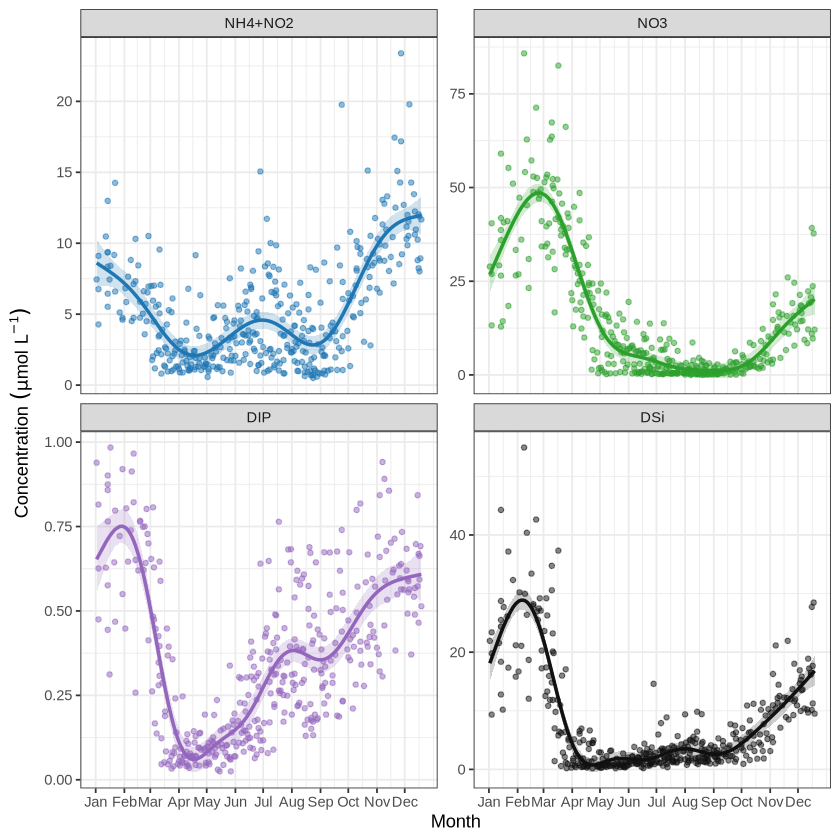

In [42]:
Nut_Light_limitation_df <- read.csv(paste(PP_cal_dir, "Nut_Light_limitation_Jetty40.csv", sep = ""))
Nut_Light_limitation_df$Lim_Nut <- factor(Nut_Light_limitation_df$Lim_Nut, levels = c("DIN", "DP", "DSi"))
Nut_Light_limitation_df$date <- Nut_Light_limitation_df$date %>% as.Date()
Nut_Light_limitation_df$NH4NO2 <- Nut_Light_limitation_df$NH4+Nut_Light_limitation_df$NO2
Nut_Light_limitation_df$N_P <- Nut_Light_limitation_df$DIN/Nut_Light_limitation_df$PO4
# Prepare dataframe
limitation_df <- Nut_Light_limitation_df[, c("date", "datum", "day_of_year", "PO4", "NH4NO2", "NO3", "Si", "N_P") ]
# plot(limitation_df$day_of_year, limitation_df$N_P, type="p")

# Fit GAM models for each limiting factor
factors <- c("PO4", "NH4NO2", "NO3", "Si")
month_days <- c(1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335)

gam_models <- list()
pred_data <- list()

for (factor in factors) {
  gam_models[[factor]] <- gam(as.formula(paste(factor, "~ s(day_of_year, k=10)")), data = limitation_df)
  pred <- predict(gam_models[[factor]], newdata = limitation_df, se.fit = TRUE)
  pred_data[[factor]] <- data.frame(
    day_of_year = limitation_df$day_of_year,
    factor = factor,
    fitted = pred$fit,
    lower = pred$fit - 1.96 * pred$se.fit,
    upper = pred$fit + 1.96 * pred$se.fit
  )
}

# Combine prediction data for plotting
plot_data <- bind_rows(pred_data)

# Build long-format observed points for each nutrient
obs_data <- cbind(day_of_year = limitation_df$day_of_year, stack(limitation_df[factors])) %>%
  as.data.frame() %>%
  rename(measured = values, factor = ind)

# Plot one nutrient per panel in a 2 x 2 layout
color_palette <- c("PO4" = "#9467BD", "NH4NO2" = "#1F77B4", "NO3" = "#2CA02C", "Si" = "#111111")

p <- ggplot(plot_data, aes(x = day_of_year, y = fitted, color = factor, fill = factor)) +
  geom_ribbon(aes(ymin = lower, ymax = upper), alpha = 0.2, color = NA) +
  geom_line(size = 1) +
  geom_point(data = obs_data, aes(x = day_of_year, y = measured, color = factor),
             inherit.aes = FALSE, alpha = 0.5, size = 1.2) +
  scale_color_manual(values = color_palette) +
  scale_fill_manual(values = color_palette) +
  scale_x_continuous(
    breaks = month_days,
    labels = month.abb) +
  facet_wrap(~ factor, ncol = 2, scales = "free_y",
             labeller = as_labeller(c(NH4NO2 = "NH4+NO2",NO3 = "NO3", PO4 = "DIP", Si = "DSi"))) +
  labs(x = "Month", y = expression(Concentration~(mu*mol~L^{-1}))) +
  theme_bw() +
  theme(legend.position = "none")
print(p)

# Save the growth rate plot as a TIFF file
#tiff(filename = paste0(graph_dir, "Nutrient_season.tiff"), 
#     width = 3000, height = 3000, res = 300)  # 300 dpi, suitable for publication
#print(p)
#dev.off()